<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_9_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For each function, I will follow this sequence:

  1. Create week_9_dataset
  2. Load the week_9_dataset
  3. Extract function
  4. Check shapes and missing values
  5. Calculate summary statistics
  6. Plot the output trend
  7. Plot the best-so-far trend
  8. Identify the best query point
  9. Plot the correlation heatmap
  10. Plot each input against the output
  11. Fit a Gaussian Process surrogate
  12. Apply UCB to generate the next query point













In [59]:
import zipfile
import os

zip_path = "/content/week_8_data.zip"
extract_path = "/content/week_8_dataset"

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"ZIP FILE NOT FOUND: {zip_path}")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully.")
print("Files inside week_8_dataset:")
print(os.listdir(extract_path))

Unzipped successfully.
Files inside week_8_dataset:
['function_1_outputs.npy', 'function_8_inputs.npy', 'function_2_inputs.npy', 'function_6_outputs.npy', 'function_5_outputs.npy', 'function_7_outputs.npy', 'function_2_outputs.npy', 'function_4_inputs.npy', 'function_1_inputs.npy', 'function_7_inputs.npy', 'function_3_inputs.npy', 'function_6_inputs.npy', 'function_5_inputs.npy', 'function_4_outputs.npy', 'function_3_outputs.npy', 'function_8_outputs.npy']


In [60]:
import numpy as np

Week_8_inputs = [np.array([0.37454 , 0.950714]), np.array([0.37454 , 0.950714]), np.array([0.444444, 0.666666, 0.333333]), np.array([0.555555, 0.444444, 0.222222, 0.111111]), np.array([0.224189, 0.84648 , 0.879484, 0.878515]), np.array([0.728186, 0.154693, 0.732552, 0.693997, 0.564013]), np.array([0.045091, 0.528666, 0.329265, 0.10535 , 0.434667, 0.641164]), np.array([0.273673, 0.2604  , 0.073937, 0.078562, 0.862321, 0.230729,
       0.108688, 0.352588])]
Week_8_inputs_2 = [np.array([0.536429, 0.835362]), np.array([0.978752, 0.932731]), np.array([0.657452, 0.998464, 0.817253]), np.array([0.00628 , 0.28184 , 0.932013, 0.960202]), np.array([0.255841, 0.841692, 0.888984, 0.86026 ]), np.array([0.433654, 0.486678, 0.282753, 0.972905, 0.323321]), np.array([0.243848, 0.9001  , 0.696978, 0.19363 , 0.374149, 0.826324]), np.array([0.16316 , 0.184786, 0.152644, 0.083802, 0.999322, 0.544113,
       0.184124, 0.123846])]
Week_8_inputs_3 = [np.array([0.614168, 0.334143]), np.array([6.00000e-06, 3.34143e-01]), np.array([0.670026, 0.057881, 0.658241]), np.array([0.394519, 0.361122, 0.256803, 0.461856]), np.array([0.255842, 0.841692, 0.888985, 0.860266]), np.array([4.95070e-01, 9.71520e-02, 6.72921e-01, 7.00000e-06, 3.51268e-01]), np.array([0.143585, 0.302559, 0.571101, 0.194533, 0.395561, 0.815792]), np.array([0.088894, 0.525132, 0.030986, 0.992538, 0.870819, 0.21706 ,
       0.011239, 0.447691])]
Week_8_inputs_4 = [np.array([0.872626, 0.321598]), np.array([0.197553, 0.808683]), np.array([0.650132, 0.218327, 0.110542]), np.array([0.715715, 0.504442, 0.275065, 0.552962]), np.array([0., 0., 0., 0.]), np.array([0.973181, 0.022807, 0.714484, 0.145453, 0.97479 ]), np.array([0.045103, 0.016167, 0.773003, 0.156031, 0.147073, 0.616114]), np.array([0.356502, 0.157574, 0.172997, 0.610561, 0.106477, 0.260297,
       0.411421, 0.90474 ])]
Week_8_inputs_5 = [np.array([0.897714, 0.081699]), np.array([0.555332, 0.360931]), np.array([0.522711, 0.090769, 0.451242]), np.array([0.713766, 0.198601, 0.014095, 0.068347]), np.array([0.754614, 0.504566, 0.432986, 0.307039]), np.array([0.824244, 0.022732, 0.960907, 0.041715, 0.89756 ]), np.array([0.025337, 0.910075, 0.72779 , 0.075231, 0.386516, 0.492629]), np.array([0.110992, 0.022977, 0.255313, 0.963757, 0.895383, 0.716713,
       0.030436, 0.083412])]
Week_8_outputs = [np.float64(-1.560646704467778e-117), np.float64(-0.03182956281754251), np.float64(-0.04090761844901528), np.float64(-8.727516493155957), np.float64(1088.8535114737463), np.float64(-1.1520351120911565), np.float64(1.0510148516295004), np.float64(9.8157087929671)]
Week_8_outputs_2 = [np.float64(1.674933466363685e-36), np.float64(0.022666631114895516), np.float64(-0.08987474979637637), np.float64(-31.73535839431216), np.float64(1035.6341457754475), np.float64(-0.8782405650300305), np.float64(0.308765180253091), np.float64(9.9399041910574)]
Week_8_outputs_3 = [np.float64(-1.0755942664604116e-32), np.float64(0.04868370128566149), np.float64(-0.18323876643005035), np.float64(-1.9810750402526334), np.float64(1035.6647479285914), np.float64(-1.339542402620705), np.float64(2.149905456773691), np.float64(8.9636037557014)]
Week_8_outputs_4 = [np.float64(-2.4666412561217706e-107), np.float64(0.038774938576018964), np.float64(-0.08251349582236739), np.float64(-9.312811809021998), np.float64(163.1225), np.float64(-2.4375082517089726), np.float64(1.2087334449610816), np.float64(9.2540644925525)]
Week_8_outputs_5 = [7.6512102255565565e-239, 0.22078072799826579, -0.05739710166867316, -17.92630659900679, 0.9401160531598542, -2.5293691850310744, 0.19078262729854223, 9.1386093113071]
Week_8_outputs_6 = [6.131855211153796e-211, 0.16053152307795218, -0.11700517654347184, -20.879363209082445, 281.9115728306016, -1.3125396070217887, 1.611967464642638, 8.5570343323444]
Week_8_outputs_7 = [-6.738616132275143e-151, 0.04871438177077586, -0.047183135414436805, -20.19585364168859, 163.1225, -1.2870894592671105, 0.8994987341856474, 8.5636390087854]
Week_8_outputs_8 = [-1.7723999829558996e-96, 0.07276416200318507, -0.07741316335640898, -28.736322947747187, 1465.5121917504077, -1.4794522548883542, 0.8461801483768777, 9.0200908822654]

In [61]:

# CREATE week_9_dataset BY APPENDING
# week_8_dataset + Week_8_inputs.txt + Week_8_outputs.txt
# This version does NOT depend on line breaks in the txt file.
# It reads all numbers, then slices them using the correct
# input dimension for each function.


import os
import re
import shutil
import numpy as np
from google.colab import drive


# 1. Mount Google Drive
drive.mount("/content/drive")


# 2. Exact file and folder paths
week8_dataset_path = "/content/week_8_dataset"
week9_dataset_path = "/content/week_9_dataset"

week8_inputs_file = "/content/Week_8_inputs.txt"
week8_outputs_file = "/content/Week_8_outputs.txt"

drive_week9_folder = "/content/drive/MyDrive/week_9_dataset"
drive_week9_zip_base = "/content/drive/MyDrive/week_9_dataset"

# 3. Check files exist
for path in [week8_dataset_path, week8_inputs_file, week8_outputs_file]:
    if os.path.exists(path):
        print("FOUND:", path)
    else:
        raise FileNotFoundError(f"MISSING: {path}")

# 4. Read all numeric values from txt file
def read_all_numbers(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    # Remove np.float64 wrappers if present
    text = text.replace("np.float64", "")

    numbers = re.findall(
        r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+(?:[eE][-+]?\d+)?",
        text
    )

    return [float(x) for x in numbers]

all_input_numbers = read_all_numbers(week8_inputs_file)
all_output_numbers = read_all_numbers(week8_outputs_file)

print("\nTotal input numbers found:", len(all_input_numbers))
print("Total output numbers found:", len(all_output_numbers))

print("\nFirst few input numbers:")
print(all_input_numbers[:20])

print("\nFirst few output numbers:")
print(all_output_numbers[:10])


# 5. Get the required input dimension for each function
function_input_dimensions = []

for i in range(1, 9):
    old_inputs_file = os.path.join(
        week8_dataset_path,
        f"function_{i}_inputs.npy"
    )

    old_inputs = np.load(old_inputs_file)
    dim = old_inputs.shape[1]
    function_input_dimensions.append(dim)

print("\nInput dimensions by function:")
for i, dim in enumerate(function_input_dimensions, start=1):
    print(f"Function {i}: {dim} input columns")

total_needed_inputs = sum(function_input_dimensions)

print("\nTotal input numbers needed:", total_needed_inputs)

if len(all_input_numbers) < total_needed_inputs:
    raise ValueError(
        f"Not enough input numbers. Needed {total_needed_inputs}, "
        f"but found {len(all_input_numbers)}."
    )

if len(all_output_numbers) < 8:
    raise ValueError(
        f"Not enough output numbers. Needed 8, "
        f"but found {len(all_output_numbers)}."
    )


# 6. Slice input numbers correctly function by function
week8_input_rows = []
start = 0

for dim in function_input_dimensions:
    end = start + dim
    row = all_input_numbers[start:end]
    week8_input_rows.append(row)
    start = end

# The first 8 output numbers correspond to Function 1 to Function 8
week8_output_values = all_output_numbers[:8]

print("\nCorrectly reconstructed Week 8 input rows:")
for i, row in enumerate(week8_input_rows, start=1):
    print(f"Function {i} input:", row)

print("\nWeek 8 output values:")
for i, value in enumerate(week8_output_values, start=1):
    print(f"Function {i} output:", value)


# 7. Create clean week_9_dataset folder
if os.path.exists(week9_dataset_path):
    shutil.rmtree(week9_dataset_path)

os.makedirs(week9_dataset_path, exist_ok=True)

# 8. Append each function
for i in range(1, 9):

    print("\n======================================")
    print(f"Processing Function {i}")
    print("======================================")

    old_inputs_file = os.path.join(
        week8_dataset_path,
        f"function_{i}_inputs.npy"
    )

    old_outputs_file = os.path.join(
        week8_dataset_path,
        f"function_{i}_outputs.npy"
    )

    old_inputs = np.load(old_inputs_file)
    old_outputs = np.load(old_outputs_file)

    if old_outputs.ndim == 1:
        old_outputs = old_outputs.reshape(-1, 1)

    input_dimension = old_inputs.shape[1]

    new_input_row = week8_input_rows[i - 1]
    new_output_value = week8_output_values[i - 1]

    new_input = np.array(new_input_row, dtype=float).reshape(1, input_dimension)
    new_output = np.array([[new_output_value]], dtype=float)

    print("Old Week 8 inputs shape:", old_inputs.shape)
    print("Old Week 8 outputs shape:", old_outputs.shape)
    print("New input shape:", new_input.shape)
    print("New output shape:", new_output.shape)

    print("New input added:", new_input)
    print("New output added:", new_output)

    week9_inputs = np.vstack([old_inputs, new_input])
    week9_outputs = np.vstack([old_outputs, new_output])

    print("Final Week 9 inputs shape:", week9_inputs.shape)
    print("Final Week 9 outputs shape:", week9_outputs.shape)

    np.save(
        os.path.join(week9_dataset_path, f"function_{i}_inputs.npy"),
        week9_inputs
    )

    np.save(
        os.path.join(week9_dataset_path, f"function_{i}_outputs.npy"),
        week9_outputs
    )

    print(f"Function {i} saved successfully.")

# 9. Save folder to Google Drive
if os.path.exists(drive_week9_folder):
    shutil.rmtree(drive_week9_folder)

shutil.copytree(week9_dataset_path, drive_week9_folder)


# 10. Create a zip in Colab and Google Drive
shutil.make_archive(
    "/content/week_9_dataset",
    "zip",
    week9_dataset_path
)

shutil.make_archive(
    drive_week9_zip_base,
    "zip",
    week9_dataset_path
)

print("\nDONE.")
print("week_9_dataset folder saved to:")
print("/content/drive/MyDrive/week_9_dataset")

print("\nweek_9_dataset zip saved to:")
print("/content/drive/MyDrive/week_9_dataset.zip")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FOUND: /content/week_8_dataset
FOUND: /content/Week_8_inputs.txt
FOUND: /content/Week_8_outputs.txt

Total input numbers found: 272
Total output numbers found: 64

First few input numbers:
[0.37454, 0.950714, 0.37454, 0.950714, 0.444444, 0.666666, 0.333333, 0.555555, 0.444444, 0.222222, 0.111111, 0.224189, 0.84648, 0.879484, 0.878515, 0.728186, 0.154693, 0.732552, 0.693997, 0.564013]

First few output numbers:
[-1.560646704467778e-117, -0.03182956281754251, -0.04090761844901528, -8.727516493155957, 1088.8535114737463, -1.1520351120911565, 1.0510148516295004, 9.8157087929671, 1.674933466363685e-36, 0.022666631114895516]

Input dimensions by function:
Function 1: 2 input columns
Function 2: 2 input columns
Function 3: 3 input columns
Function 4: 4 input columns
Function 5: 4 input columns
Function 6: 5 input columns
Function 7: 6 input columns
Function 8: 8 inp

In [99]:

# WEEK DATASET INTEGRITY CHECKER AND FIXER
# Fixes mismatched input/output lengths for all functions


import os
import numpy as np
import pandas as pd

def check_and_fix_function_dataset(
    function_number,
    dataset_folder,
    fix=True,
    save_backup=True
):
    """
    Checks whether function inputs and outputs have the same number of rows.

    If fix=True:
    - If inputs have more rows than outputs, trim extra input rows.
    - If outputs have more rows than inputs, trim extra output values.
    - Save the corrected .npy files back into the dataset folder.

    This prevents:
    ValueError: Length of values does not match length of index
    """

    input_file = os.path.join(dataset_folder, f"function_{function_number}_inputs.npy")
    output_file = os.path.join(dataset_folder, f"function_{function_number}_outputs.npy")

    if not os.path.exists(input_file):
        raise FileNotFoundError(f"Missing input file: {input_file}")

    if not os.path.exists(output_file):
        raise FileNotFoundError(f"Missing output file: {output_file}")

    X = np.load(input_file)
    y = np.load(output_file)

    y = np.ravel(y)

    n_inputs = X.shape[0]
    n_outputs = y.shape[0]

    print("=" * 70)
    print(f"Function {function_number}")
    print("Input shape:", X.shape)
    print("Output shape:", y.shape)

    if n_inputs == n_outputs:
        print("Status: OK — inputs and outputs match.")
        return X, y

    print("Status: MISMATCH FOUND")
    print(f"Inputs rows:  {n_inputs}")
    print(f"Output rows:  {n_outputs}")

    if not fix:
        raise ValueError(
            f"Function {function_number} mismatch: "
            f"{n_inputs} inputs but {n_outputs} outputs."
        )

    # Save backup before correction
    if save_backup:
        backup_input_file = input_file.replace(".npy", "_backup_before_fix.npy")
        backup_output_file = output_file.replace(".npy", "_backup_before_fix.npy")

        np.save(backup_input_file, X)
        np.save(backup_output_file, y)

        print("Backup saved:")
        print(backup_input_file)
        print(backup_output_file)

    # Trim both to the shorter length
    min_len = min(n_inputs, n_outputs)

    X_fixed = X[:min_len]
    y_fixed = y[:min_len]

    np.save(input_file, X_fixed)
    np.save(output_file, y_fixed)

    print("Fixed by trimming to shortest matching length:", min_len)
    print("New input shape:", X_fixed.shape)
    print("New output shape:", y_fixed.shape)

    return X_fixed, y_fixed

In [101]:

# CHECK AND FIX ALL FUNCTIONS BEFORE BO


for f in range(1, 9):
    X_fixed, y_fixed = check_and_fix_function_dataset(
        function_number=f,
        dataset_folder=week9_path,
        fix=True,
        save_backup=True
    )

Function 1
Input shape: (18, 2)
Output shape: (18,)
Status: OK — inputs and outputs match.
Function 2
Input shape: (18, 2)
Output shape: (18,)
Status: OK — inputs and outputs match.
Function 3
Input shape: (23, 3)
Output shape: (23,)
Status: OK — inputs and outputs match.
Function 4
Input shape: (38, 4)
Output shape: (38,)
Status: OK — inputs and outputs match.
Function 5
Input shape: (28, 4)
Output shape: (28,)
Status: OK — inputs and outputs match.
Function 6
Input shape: (28, 5)
Output shape: (28,)
Status: OK — inputs and outputs match.
Function 7
Input shape: (38, 6)
Output shape: (38,)
Status: OK — inputs and outputs match.
Function 8
Input shape: (47, 8)
Output shape: (47,)
Status: OK — inputs and outputs match.


In [102]:

# EDA SETUP FOR WEEK 9 DATASET
# Function by Function


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path to your Week 9 dataset
week9_dataset_path = "/content/week_9_dataset"

# Check files inside week_9_dataset
print("Files inside week_9_dataset:")
for file in os.listdir(week9_dataset_path):
    print(file)

Files inside week_9_dataset:
function_1_outputs.npy
function_8_inputs.npy
function_2_inputs.npy
function_6_outputs.npy
function_5_outputs.npy
function_7_outputs.npy
function_8_inputs_backup_before_fix.npy
function_2_outputs.npy
function_8_outputs_backup_before_fix.npy
function_4_inputs.npy
function_1_inputs.npy
function_7_inputs.npy
function_3_inputs.npy
function_6_inputs.npy
function_5_inputs.npy
function_4_outputs.npy
function_3_outputs.npy
function_8_outputs.npy


In [103]:

# FUNCTION-BY-FUNCTION EDA CODE


def run_function_eda(function_id, dataset_path="/content/week_9_dataset"):

    print("=" * 60)
    print(f"EDA FOR FUNCTION {function_id}")
    print("=" * 60)

    # --------------------------------------------------------
    # 1. Load inputs and outputs
    # --------------------------------------------------------

    inputs_file = os.path.join(dataset_path, f"function_{function_id}_inputs.npy")
    outputs_file = os.path.join(dataset_path, f"function_{function_id}_outputs.npy")

    X = np.load(inputs_file)
    y = np.load(outputs_file)

    if y.ndim == 2:
        y = y.ravel()

    print("\n1. DATA SHAPES")
    print("Input shape X:", X.shape)
    print("Output shape y:", y.shape)

    # --------------------------------------------------------
    # 2. Convert to DataFrame
    # --------------------------------------------------------

    input_columns = [f"x{i+1}" for i in range(X.shape[1])]

    df_X = pd.DataFrame(X, columns=input_columns)
    df_y = pd.DataFrame(y, columns=["output"])

    df = pd.concat([df_X, df_y], axis=1)

    print("\n2. FIRST FIVE ROWS")
    display(df.head())

    # --------------------------------------------------------
    # 3. Missing values
    # --------------------------------------------------------

    print("\n3. MISSING VALUES")
    display(df.isnull().sum())

    # --------------------------------------------------------
    # 4. Summary statistics
    # --------------------------------------------------------

    print("\n4. SUMMARY STATISTICS")
    display(df.describe())

    # --------------------------------------------------------
    # 5. Best output and best query point
    # --------------------------------------------------------

    best_index = df["output"].idxmax()
    best_output = df.loc[best_index, "output"]
    best_query_point = df.loc[best_index, input_columns]

    print("\n5. BEST QUERY POINT")
    print("Best row index:", best_index)
    print("Best output value:", best_output)
    print("Best input values:")
    display(best_query_point)

    # --------------------------------------------------------
    # 6. Output trend plot
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["output"], marker="o")
    plt.title(f"Function {function_id}: Output Trend")
    plt.xlabel("Observation Number")
    plt.ylabel("Output")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # 7. Best-so-far plot
    # --------------------------------------------------------

    df["best_so_far"] = df["output"].cummax()

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["best_so_far"], marker="o")
    plt.title(f"Function {function_id}: Best-So-Far Output")
    plt.xlabel("Observation Number")
    plt.ylabel("Best Output So Far")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # 8. Correlation table
    # --------------------------------------------------------

    print("\n8. CORRELATION WITH OUTPUT")
    correlation_with_output = df.corr(numeric_only=True)["output"].sort_values(ascending=False)
    display(correlation_with_output)

    # --------------------------------------------------------
    # 9. Correlation heatmap using matplotlib
    # --------------------------------------------------------

    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title(f"Function {function_id}: Correlation Heatmap")
    plt.show()

    # --------------------------------------------------------
    # 10. Input-output scatter plots
    # --------------------------------------------------------

    for col in input_columns:
        plt.figure(figsize=(7, 5))
        plt.scatter(df[col], df["output"])
        plt.title(f"Function {function_id}: {col} vs Output")
        plt.xlabel(col)
        plt.ylabel("Output")
        plt.grid(True)
        plt.show()

    return df

EDA FOR FUNCTION 1

1. DATA SHAPES
Input shape X: (18, 2)
Output shape y: (18,)

2. FIRST FIVE ROWS


,x1,x2,output
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03



3. MISSING VALUES


,0
x1,0
x2,0
output,0



4. SUMMARY STATISTICS


,x1,x2,output
count,18.000000,18.000000,1.800000e+01
mean,0.528151,0.628428,1.422202e+01
std,0.246322,0.353347,2.737884e+01
min,0.082507,0.078723,-3.606063e-03
25%,0.374540,0.299421,7.651210e-239
50%,0.392489,0.747980,6.793724e-80
75%,0.719122,0.950714,5.783156e-16
max,0.897714,0.999543,6.400000e+01



5. BEST QUERY POINT
Best row index: 10
Best output value: 64.0
Best input values:


,10
x1,0.374540
x2,0.950714


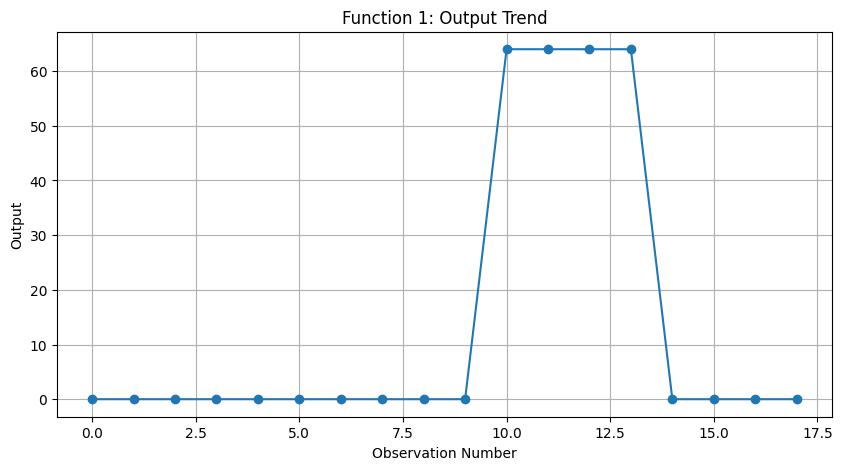

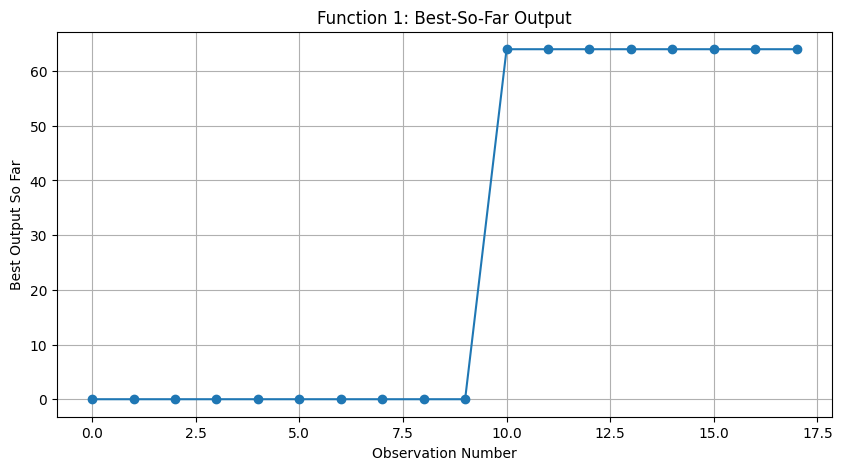


8. CORRELATION WITH OUTPUT


,output
output,1.000000
best_so_far,0.597619
x2,0.501666
x1,-0.343004


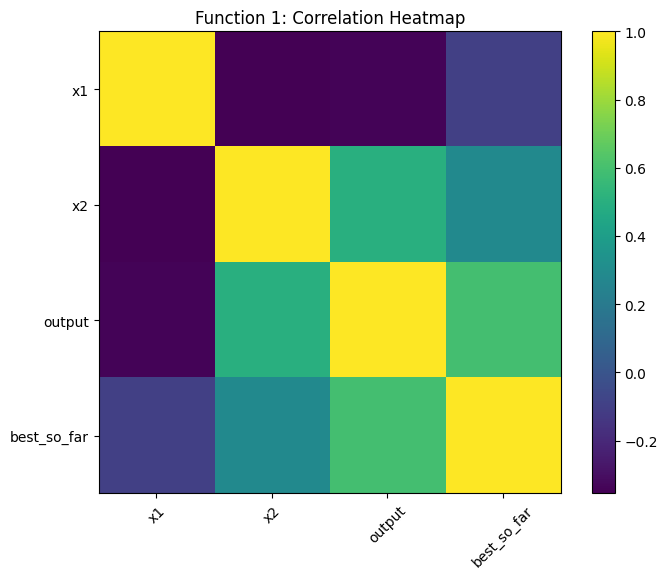

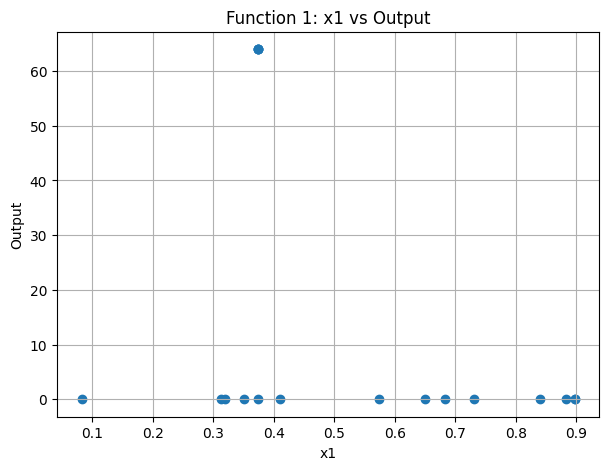

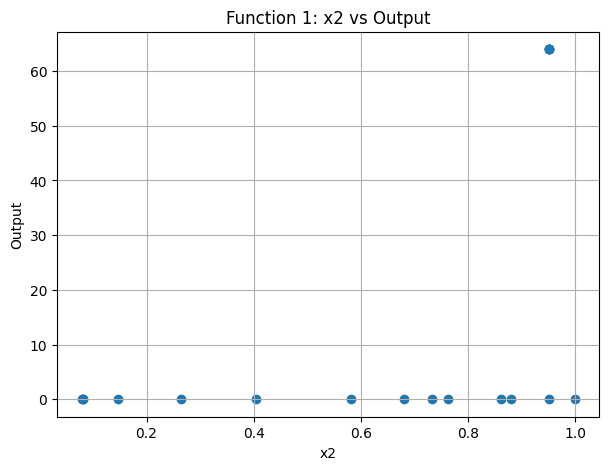

In [64]:

# EDA FOR FUNCTION 1
df_function_1 = run_function_eda(function_id=1)

EDA FOR FUNCTION 2

1. DATA SHAPES
Input shape X: (18, 2)
Output shape y: (18,)

2. FIRST FIVE ROWS


,x1,x2,output
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965



3. MISSING VALUES


,0
x1,0
x2,0
output,0



4. SUMMARY STATISTICS


,x1,x2,output
count,18.000000,18.000000,1.800000e+01
mean,0.465454,0.630812,3.709177e+00
std,0.220282,0.336132,1.504796e+01
min,0.009675,0.028698,-6.562362e-02
25%,0.374540,0.351987,-1.560647e-117
50%,0.406353,0.741547,1.318394e-01
75%,0.572118,0.950714,2.816495e-01
max,0.877791,0.999881,6.400000e+01



5. BEST QUERY POINT
Best row index: 13
Best output value: 64.0
Best input values:


,13
x1,0.374540
x2,0.950714


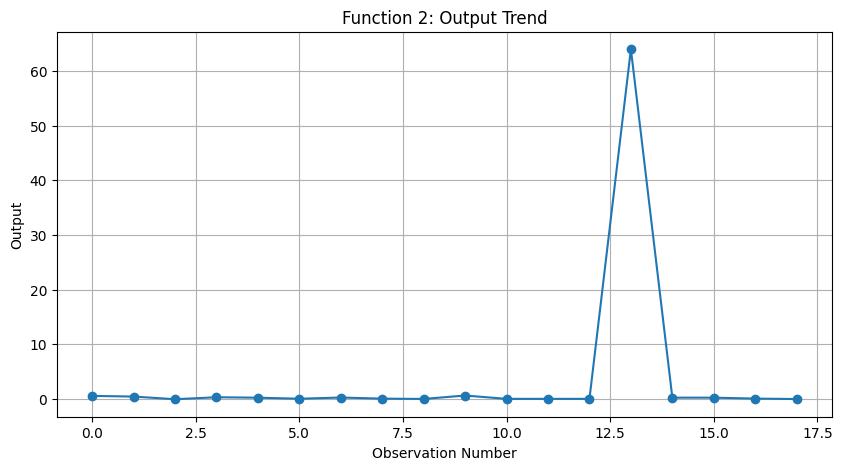

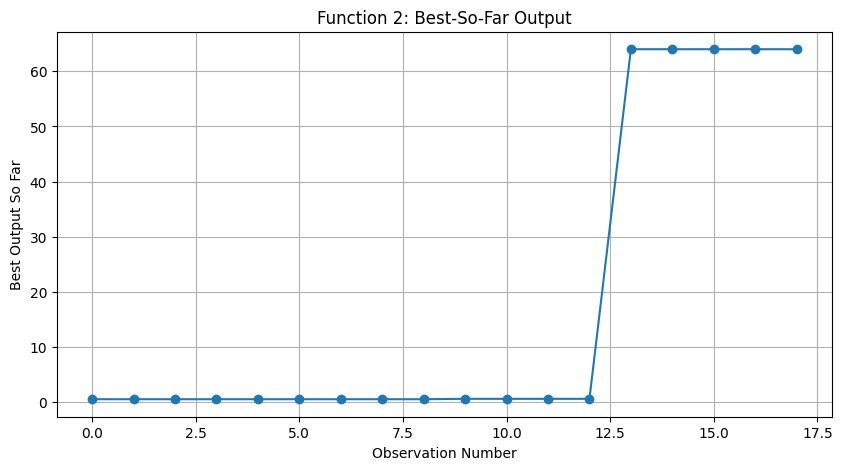


8. CORRELATION WITH OUTPUT


,output
output,1.000000
best_so_far,0.389411
x2,0.236081
x1,-0.093135


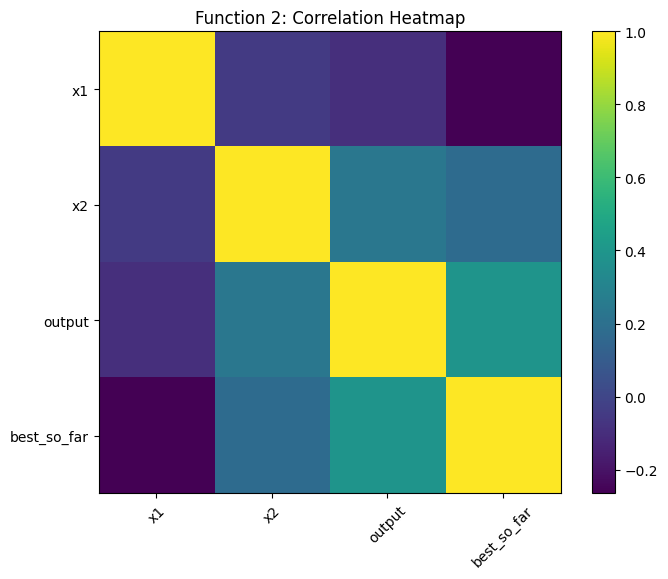

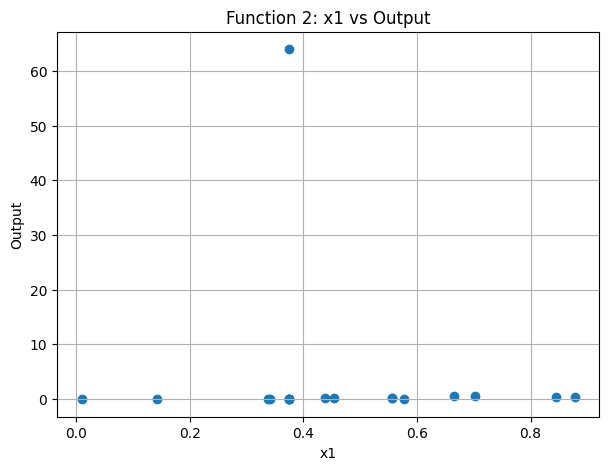

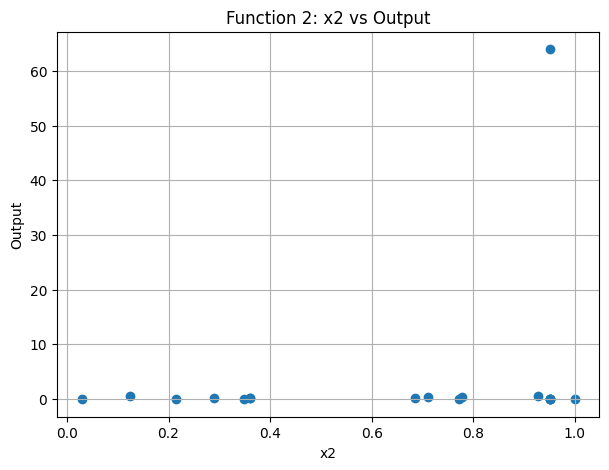

In [65]:
# EDA FOR FUNCTION 2
df_function_2 = run_function_eda(function_id=2)

EDA FOR FUNCTION 3

1. DATA SHAPES
Input shape X: (23, 3)
Output shape y: (23,)

2. FIRST FIVE ROWS


,x1,x2,x3,output
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008



3. MISSING VALUES


,0
x1,0
x2,0
x3,0
output,0



4. SUMMARY STATISTICS


,x1,x2,x3,output
count,23.000000,23.000000,23.000000,23.000000
mean,0.427407,0.519555,0.389354,11.051722
std,0.221938,0.239158,0.229478,24.840451
min,0.046809,0.090709,0.066089,-0.398926
25%,0.231332,0.320871,0.259050,-0.111018
50%,0.444444,0.644074,0.333333,-0.057397
75%,0.528808,0.668238,0.451492,-0.038643
max,0.965995,0.941360,0.990882,64.000000



5. BEST QUERY POINT
Best row index: 15
Best output value: 64.0
Best input values:


,15
x1,0.444444
x2,0.666666
x3,0.333333


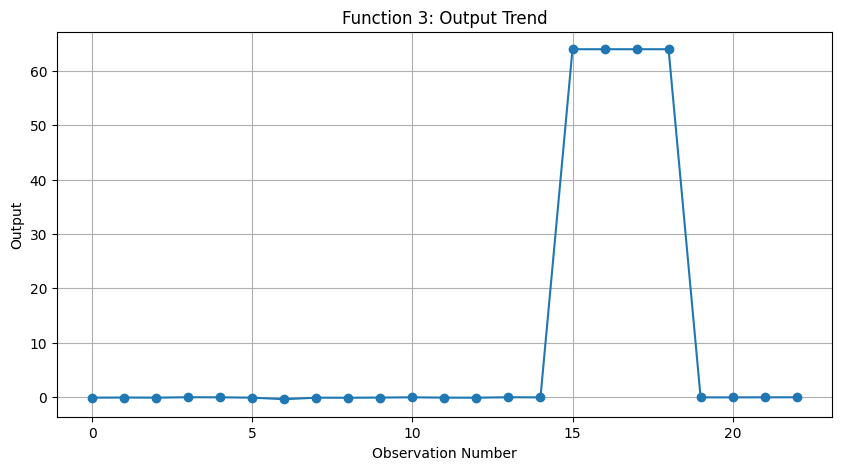

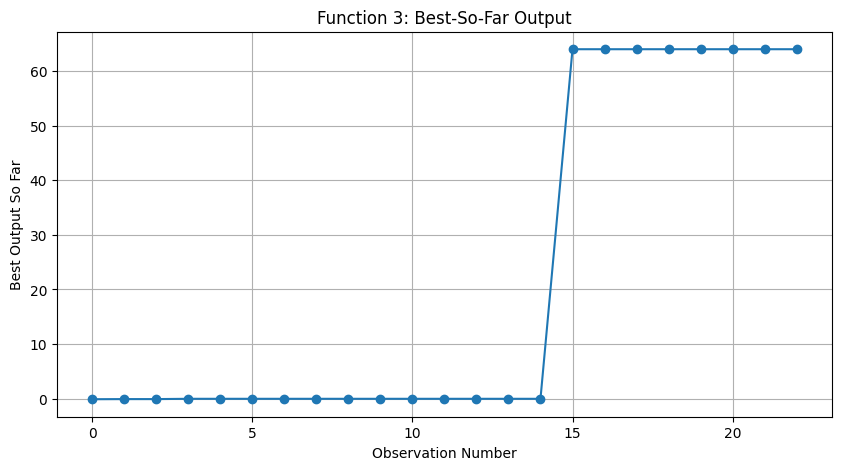


8. CORRELATION WITH OUTPUT


,output
output,1.000000
best_so_far,0.628948
x2,0.288793
x1,0.036802
x3,-0.116138


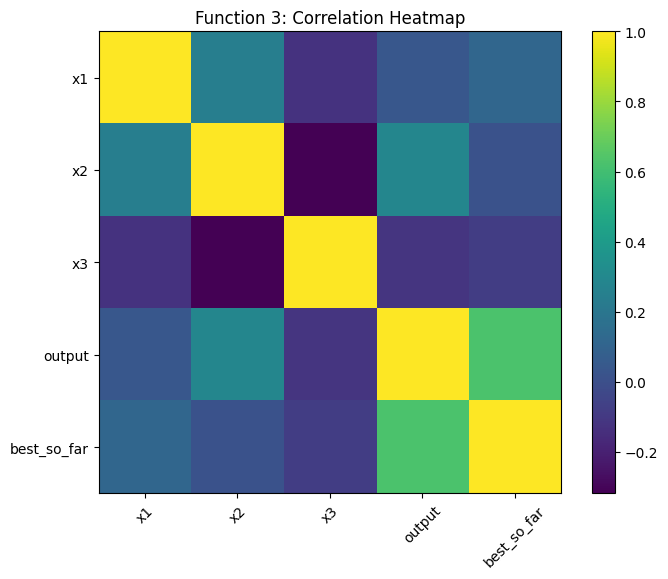

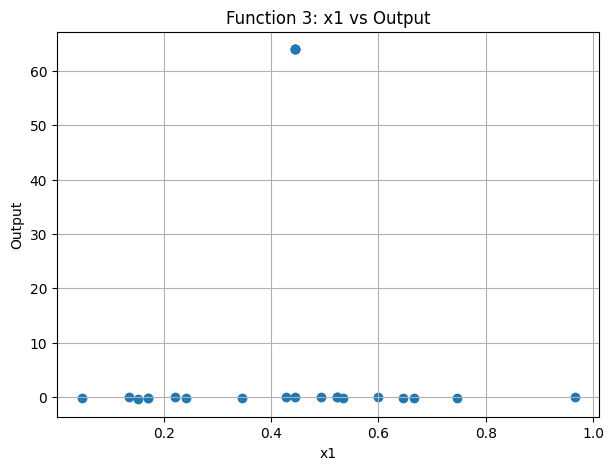

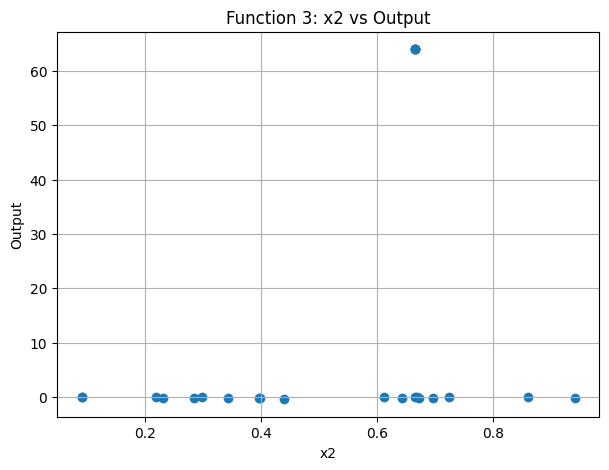

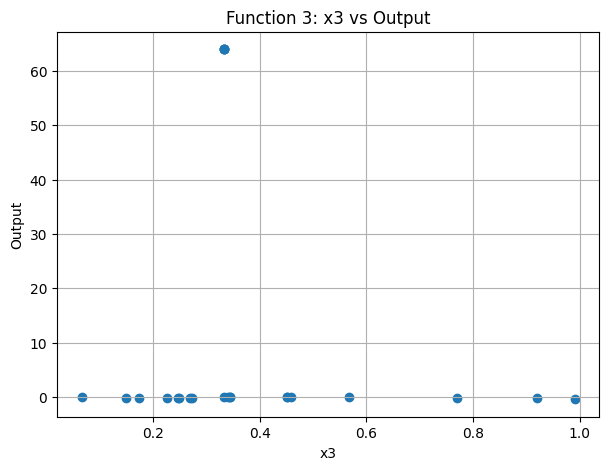

In [66]:
# EDA FOR FUNCTION 3
df_function_3 = run_function_eda(function_id=3)

EDA FOR FUNCTION 4

1. DATA SHAPES
Input shape X: (38, 4)
Output shape y: (38,)

2. FIRST FIVE ROWS


,x1,x2,x3,x4,output
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633



3. MISSING VALUES


,0
x1,0
x2,0
x3,0
x4,0
output,0



4. SUMMARY STATISTICS


,x1,x2,x3,x4,output
count,38.000000,38.000000,38.000000,38.000000,38.000000
mean,0.541776,0.446357,0.398511,0.394539,-13.632345
std,0.273398,0.289141,0.270364,0.302450,15.204399
min,0.037825,0.006250,0.014095,0.068347,-32.625660
25%,0.293123,0.174215,0.208914,0.111111,-19.852513
50%,0.555555,0.458405,0.352386,0.270500,-15.756741
75%,0.737163,0.666413,0.650181,0.679527,-11.599290
max,0.985622,0.919592,0.939178,0.999483,64.000000



5. BEST QUERY POINT
Best row index: 33
Best output value: 64.0
Best input values:


,33
x1,0.555555
x2,0.444444
x3,0.222222
x4,0.111111


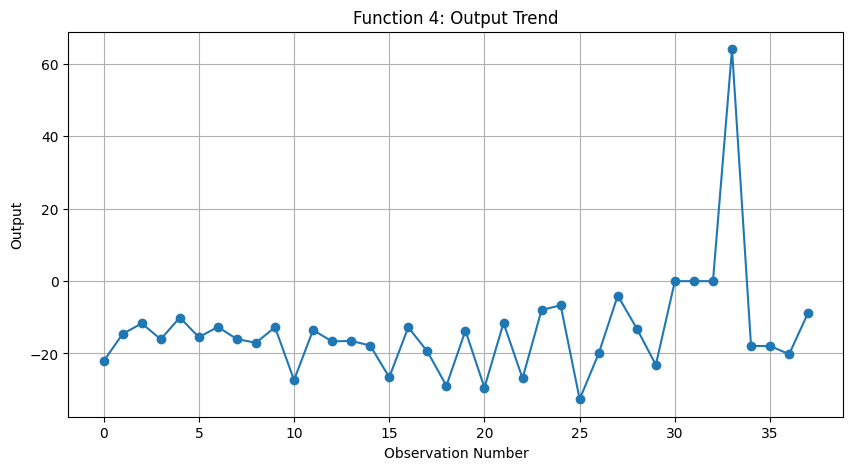

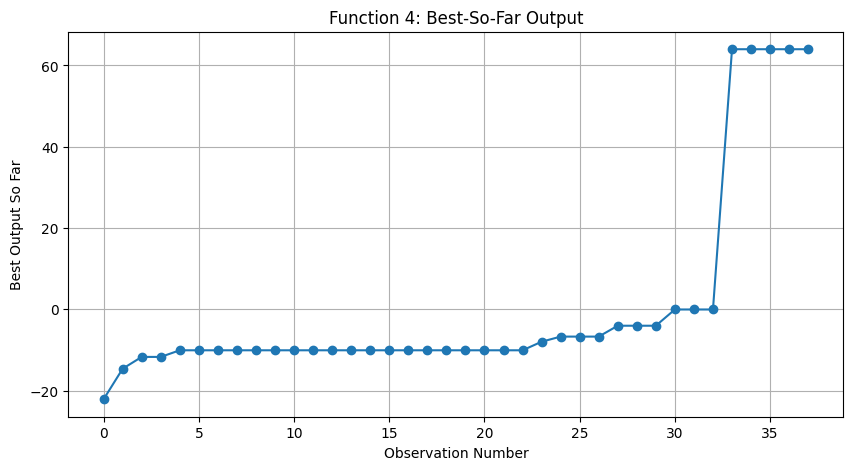


8. CORRELATION WITH OUTPUT


,output
output,1.000000
best_so_far,0.384343
x2,-0.182554
x3,-0.183470
x1,-0.193934
x4,-0.416641


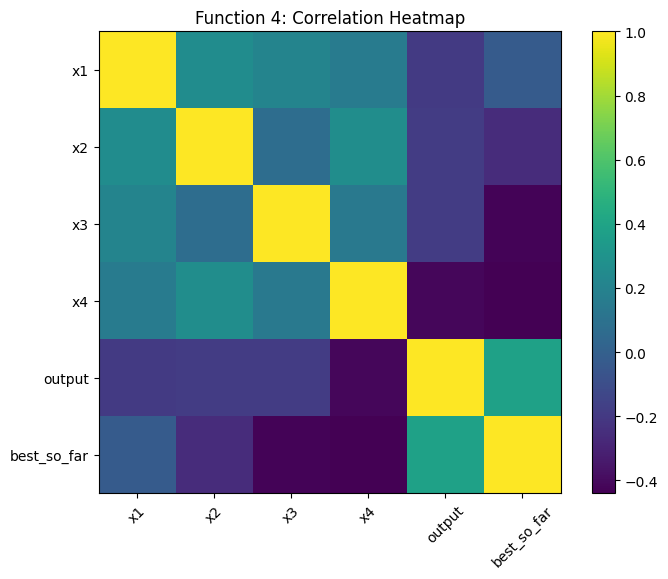

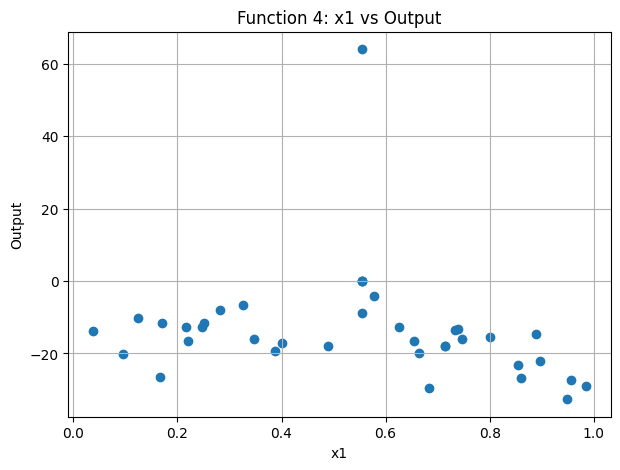

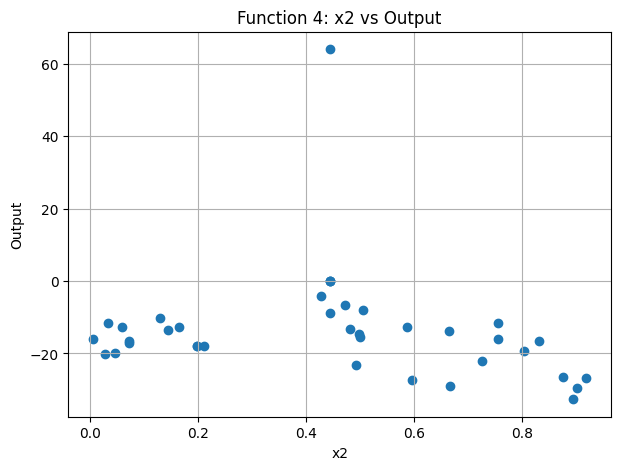

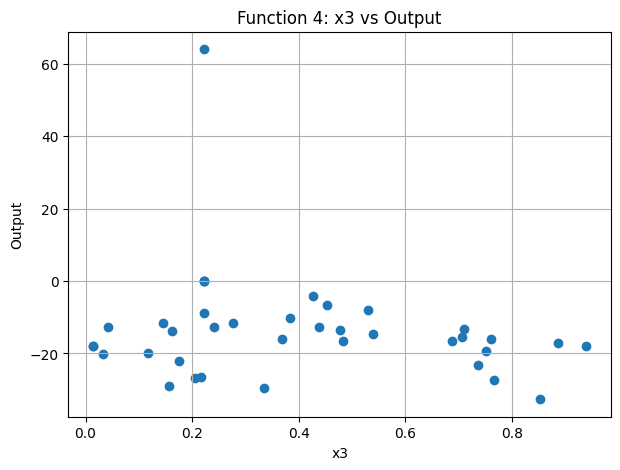

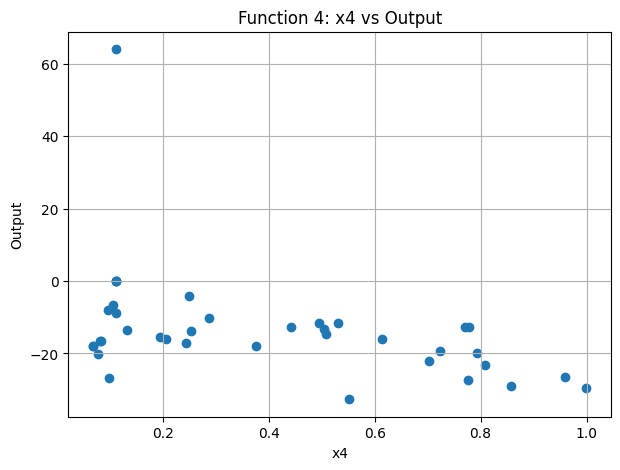

In [67]:
# EDA FOR FUNCTION 4
df_function_4 = run_function_eda(function_id=4)

EDA FOR FUNCTION 5

1. DATA SHAPES
Input shape X: (28, 4)
Output shape y: (28,)

2. FIRST FIVE ROWS


,x1,x2,x3,x4,output
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525



3. MISSING VALUES


,0
x1,0
x2,0
x3,0
x4,0
output,0



4. SUMMARY STATISTICS


,x1,x2,x3,x4,output
count,28.000000,28.000000,28.000000,28.000000,28.000000
mean,0.422783,0.543309,0.529367,0.532180,161.974777
std,0.243833,0.286762,0.280335,0.323189,282.699182
min,0.000000,0.000000,0.000000,0.000000,0.112940
25%,0.224189,0.320901,0.342025,0.277909,22.892661
50%,0.396916,0.583271,0.543505,0.477600,64.000000
75%,0.678976,0.825088,0.784883,0.878515,122.959532
max,0.836478,0.862540,0.879484,0.957644,1088.859618



5. BEST QUERY POINT
Best row index: 15
Best output value: 1088.8596181962705
Best input values:


,15
x1,0.224189
x2,0.846480
x3,0.879484
x4,0.878516


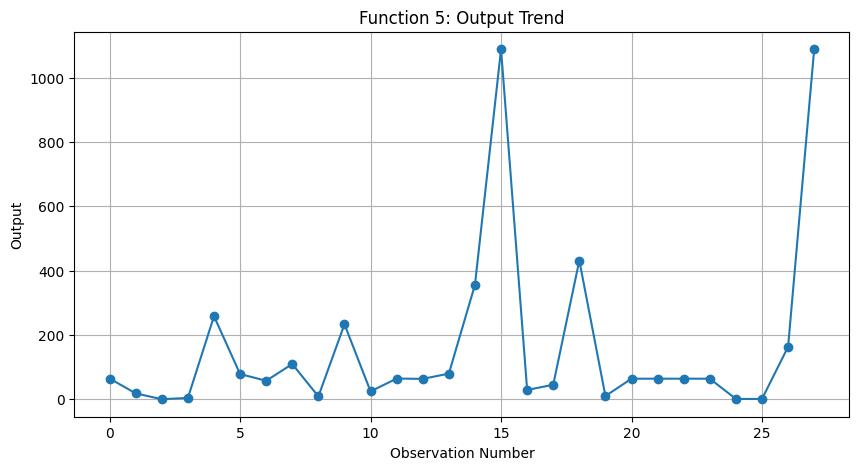

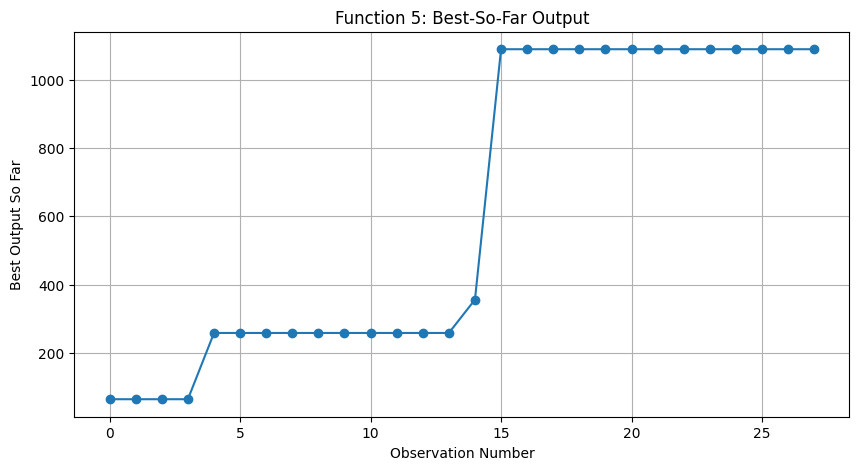


8. CORRELATION WITH OUTPUT


,output
output,1.000000
x4,0.448628
x2,0.316884
x3,0.309707
best_so_far,0.280986
x1,-0.285273


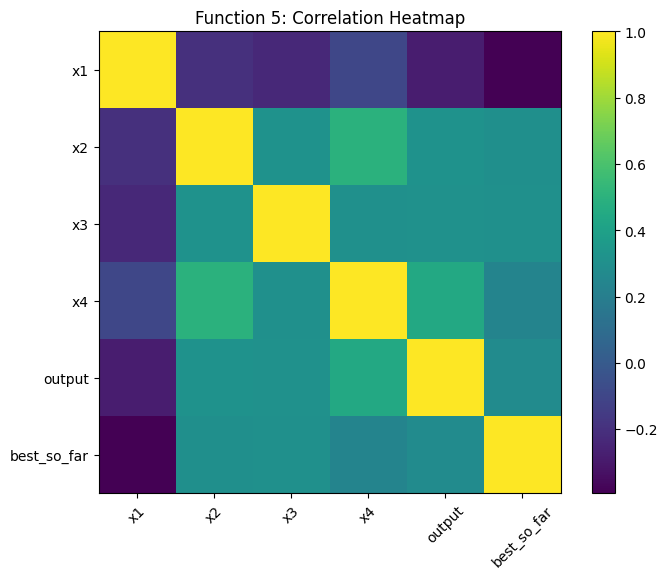

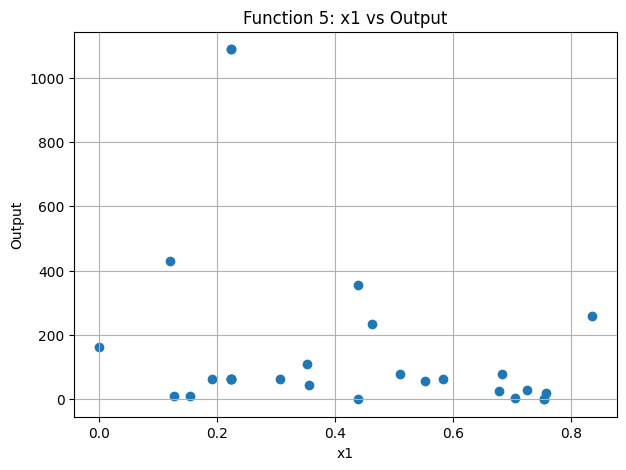

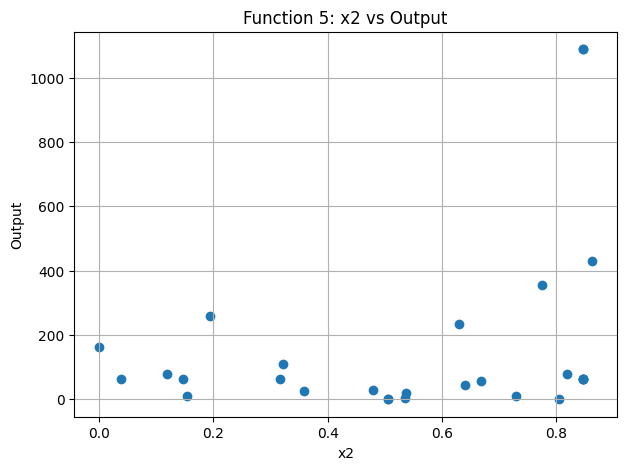

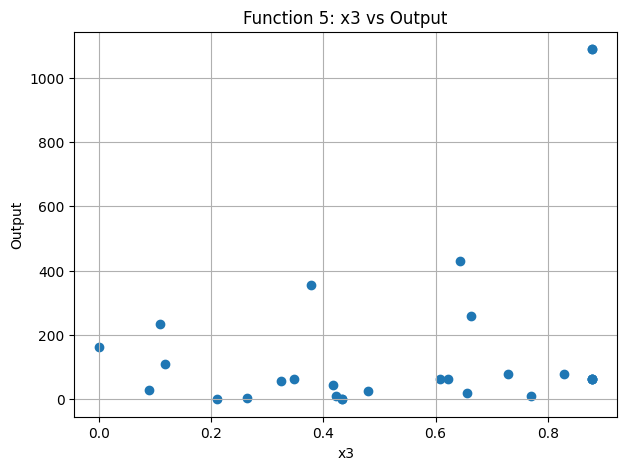

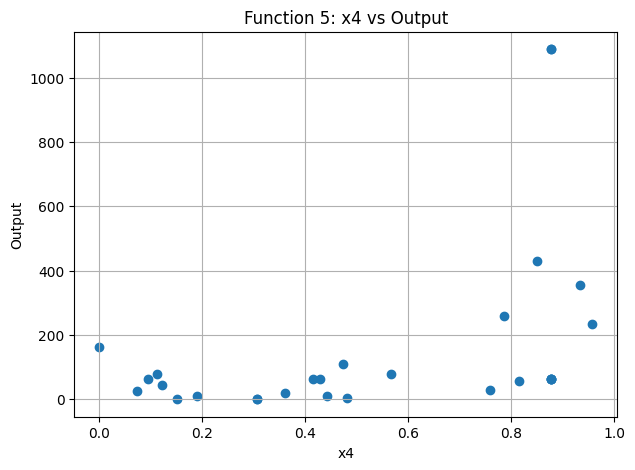

In [68]:
# EDA FOR FUNCTION 5
df_function_5 = run_function_eda(function_id=5)

EDA FOR FUNCTION 6

1. DATA SHAPES
Input shape X: (28, 5)
Output shape y: (28,)

2. FIRST FIVE ROWS


,x1,x2,x3,x4,x5,output
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237



3. MISSING VALUES


,0
x1,0
x2,0
x3,0
x4,0
x5,0
output,0



4. SUMMARY STATISTICS


,x1,x2,x3,x4,x5,output
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,0.604591,0.432342,0.560957,0.535100,0.489979,0.945415
std,0.271367,0.318922,0.309044,0.282039,0.281860,12.376072
min,0.021735,0.022732,0.016523,0.041715,0.004911,-2.571170
25%,0.437550,0.154693,0.394364,0.329066,0.264230,-1.713639
50%,0.728186,0.320292,0.693947,0.679768,0.564013,-1.301682
75%,0.773685,0.759499,0.743885,0.696748,0.639746,-1.092528
max,0.957740,0.931871,0.978806,0.961656,0.897560,64.000000



5. BEST QUERY POINT
Best row index: 23
Best output value: 64.0
Best input values:


,23
x1,0.728186
x2,0.154693
x3,0.732552
x4,0.693997
x5,0.564013


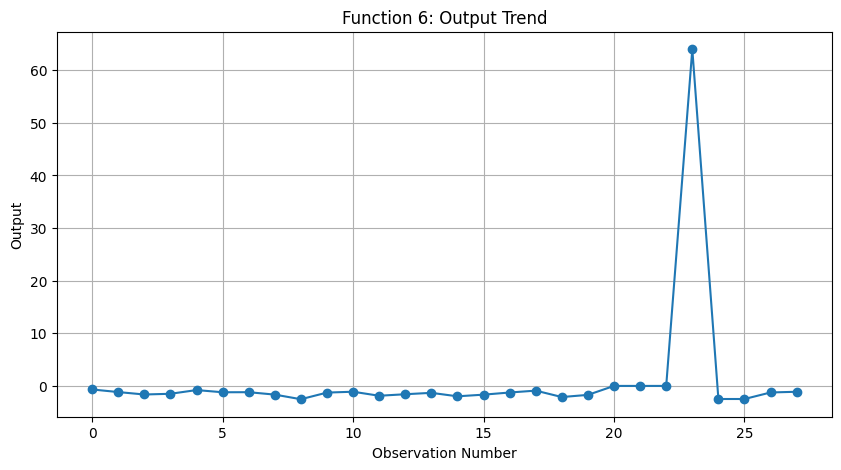

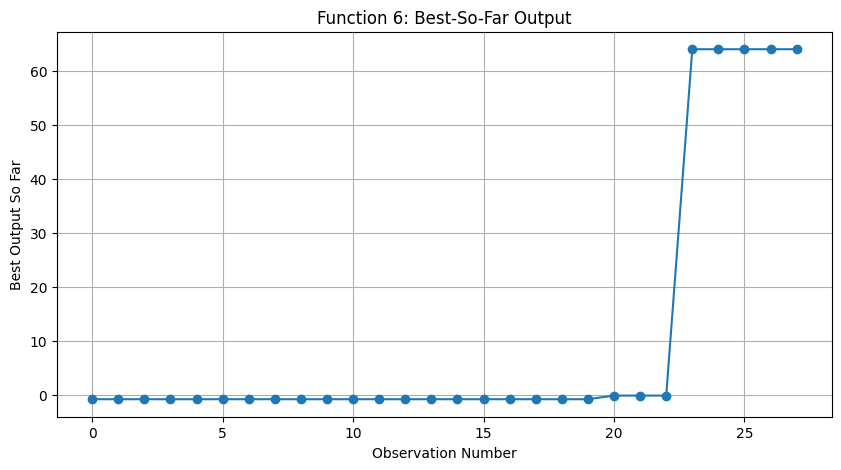


8. CORRELATION WITH OUTPUT


,output
output,1.000000
best_so_far,0.397560
x4,0.143397
x3,0.115991
x1,0.093649
x5,0.030412
x2,-0.183426


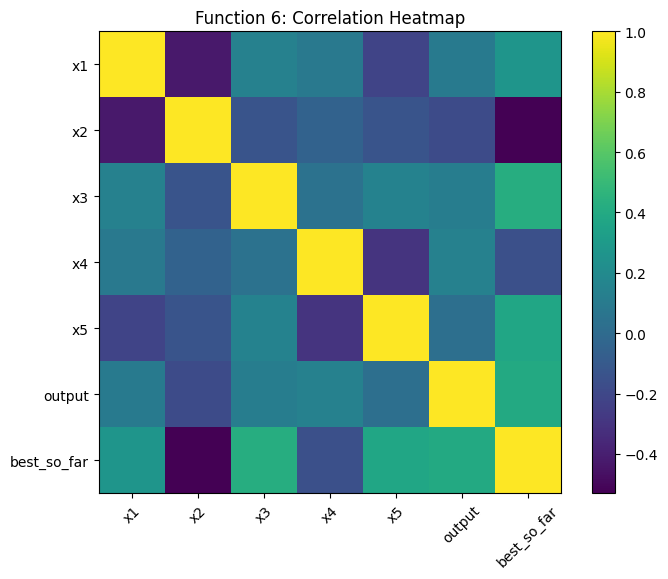

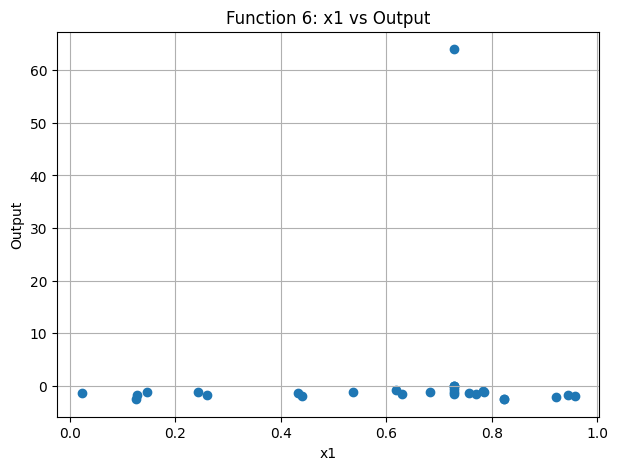

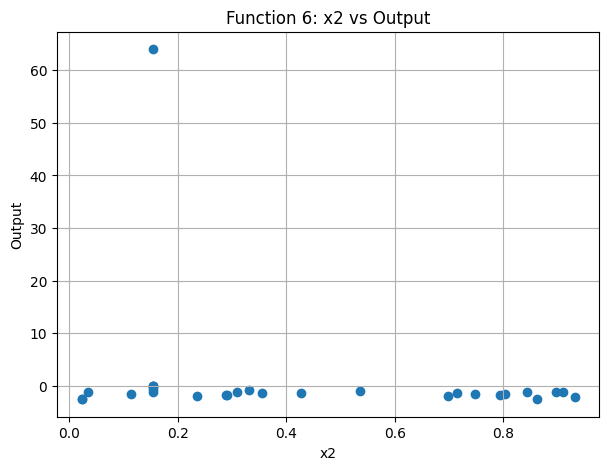

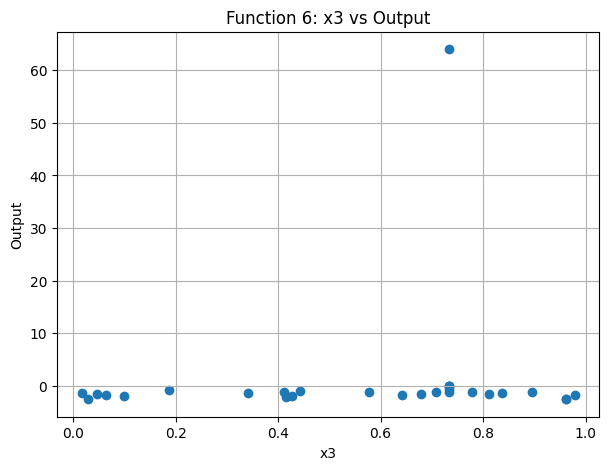

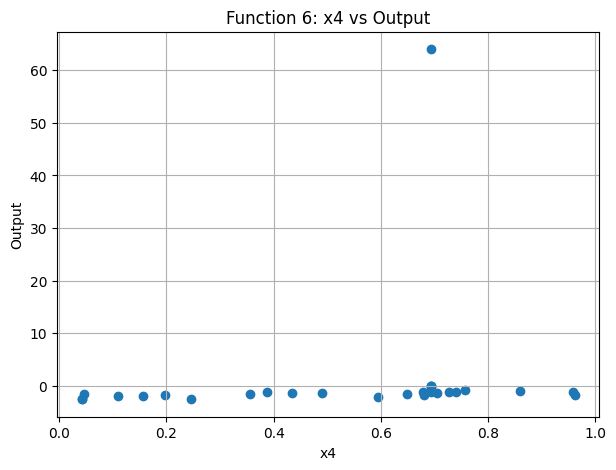

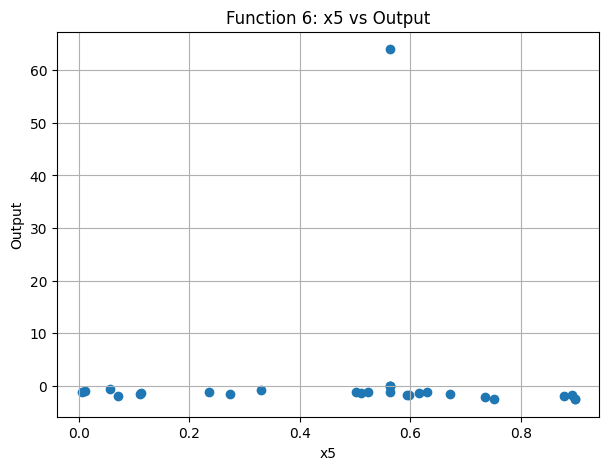

In [69]:
# EDA FOR FUNCTION 6
df_function_6 = run_function_eda(function_id=6)

EDA FOR FUNCTION 7

1. DATA SHAPES
Input shape X: (38, 6)
Output shape y: (38,)

2. FIRST FIVE ROWS


,x1,x2,x3,x4,x5,x6,output
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047



3. MISSING VALUES


,0
x1,0
x2,0
x3,0
x4,0
x5,0
x6,0
output,0



4. SUMMARY STATISTICS


,x1,x2,x3,x4,x5,x6,output
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,0.414470,0.444274,0.396660,0.423672,0.456239,0.508510,6.971598
std,0.329150,0.254698,0.290222,0.327116,0.279717,0.244736,19.825763
min,0.025337,0.011813,0.003635,0.037758,0.014944,0.051100,0.002701
25%,0.079457,0.272943,0.160967,0.110105,0.260415,0.351310,0.024398
50%,0.368718,0.490242,0.329265,0.300538,0.434667,0.605131,0.145645
75%,0.725368,0.547338,0.662281,0.750193,0.689444,0.651948,0.594013
max,0.942451,0.924694,0.924571,0.961017,0.998655,0.951014,64.000000



5. BEST QUERY POINT
Best row index: 30
Best output value: 64.0
Best input values:


,30
x1,0.045091
x2,0.528666
x3,0.329265
x4,0.105350
x5,0.434667
x6,0.641164


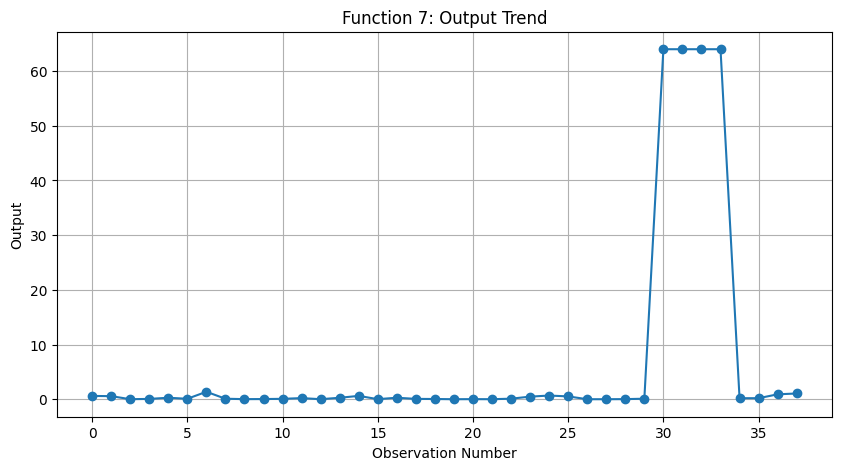

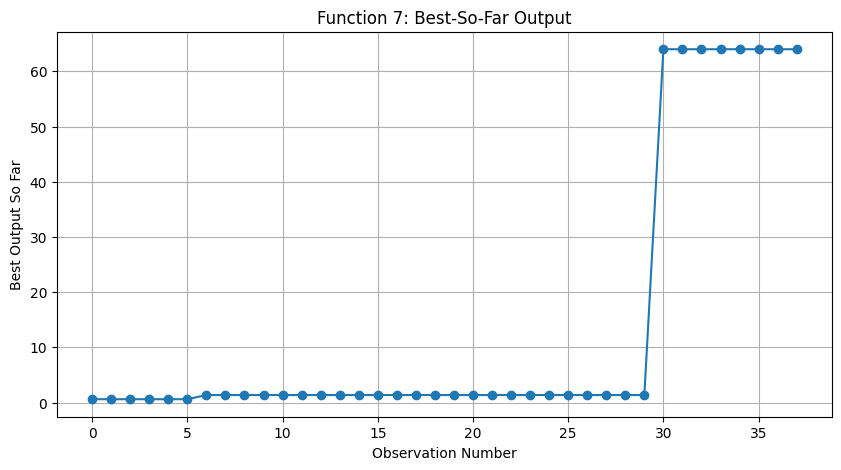


8. CORRELATION WITH OUTPUT


,output
output,1.000000
best_so_far,0.668309
x6,0.193552
x2,0.116415
x5,-0.032326
x3,-0.079149
x4,-0.341433
x1,-0.396154


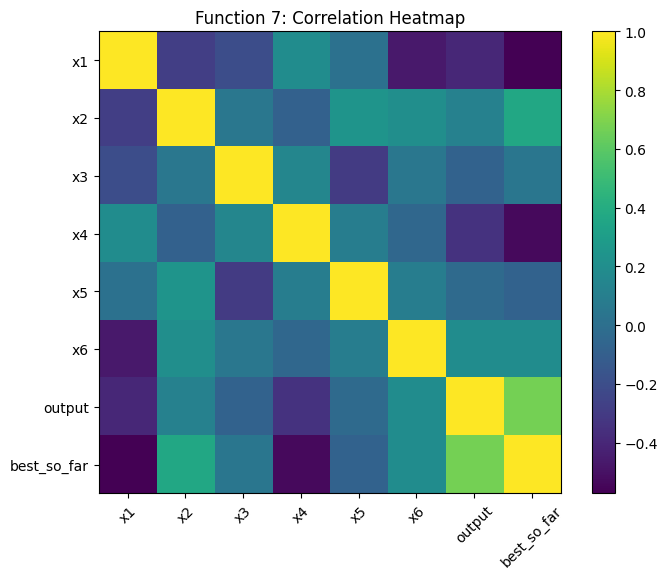

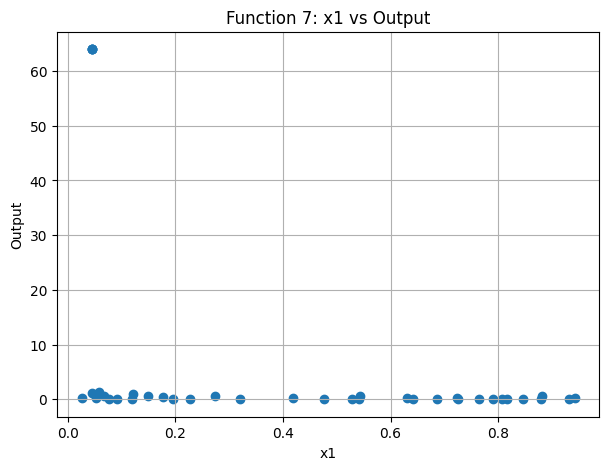

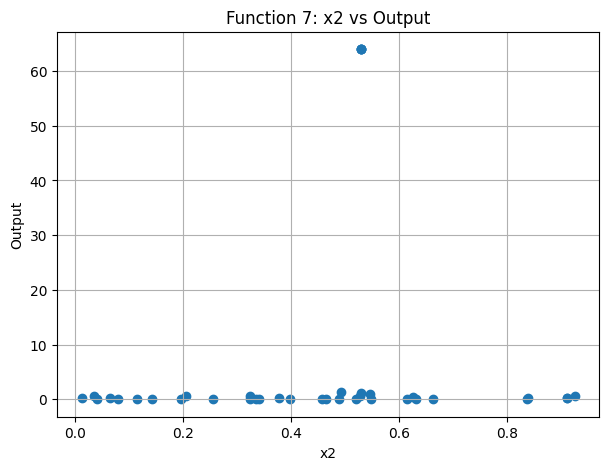

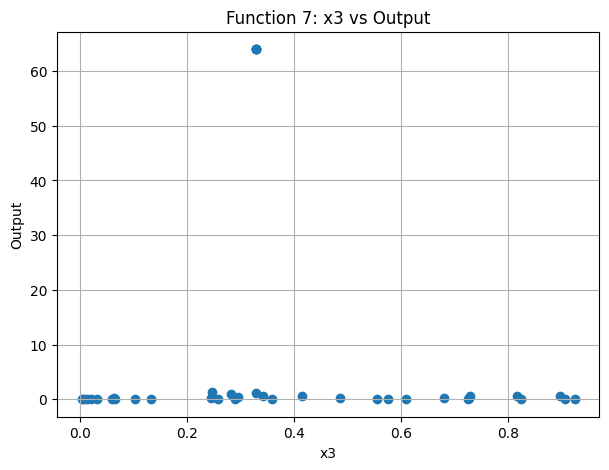

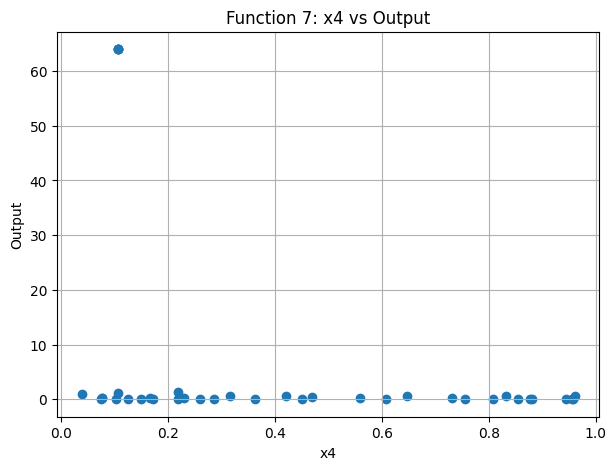

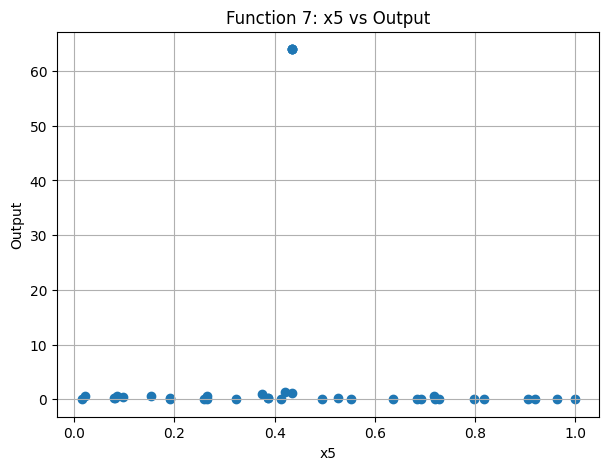

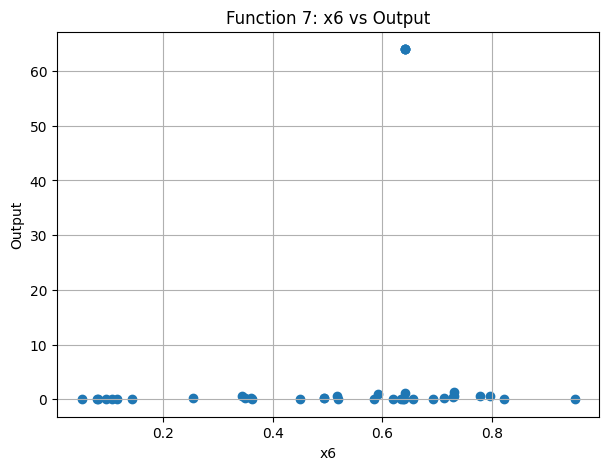

In [70]:
# EDA FOR FUNCTION 7
df_function_7 = run_function_eda(function_id=7)

EDA FOR FUNCTION 8

1. DATA SHAPES
Input shape X: (47, 8)
Output shape y: (48,)

2. FIRST FIVE ROWS


,x1,x2,x3,x4,x5,x6,x7,x8,output
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117



3. MISSING VALUES


,0
x1,1
x2,1
x3,1
x4,1
x5,1
x6,1
x7,1
x8,1
output,0



4. SUMMARY STATISTICS


,x1,x2,x3,x4,x5,x6,x7,x8,output
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,48.000000
mean,0.484734,0.452699,0.470624,0.403576,0.511699,0.435677,0.521695,0.472689,8.064271
std,0.313748,0.299450,0.306737,0.274607,0.290398,0.279870,0.287901,0.274953,9.246815
min,0.006802,0.003419,0.022929,0.009043,0.009649,0.022113,0.035909,0.041956,-8.727516
25%,0.233156,0.252090,0.235292,0.125604,0.255520,0.230729,0.246071,0.293995,7.127082
50%,0.472071,0.458759,0.416796,0.424597,0.503199,0.382655,0.557295,0.446838,7.940817
75%,0.778582,0.676618,0.728788,0.650684,0.738962,0.680609,0.759155,0.695357,8.658977
max,0.985945,0.973980,0.998885,0.902986,0.986902,0.990244,0.992914,0.988755,64.000000



5. BEST QUERY POINT
Best row index: 43
Best output value: 64.0
Best input values:


,43
x1,0.273673
x2,0.260400
x3,0.073937
x4,0.078562
x5,0.862321
x6,0.230729
x7,0.108688
x8,0.110992


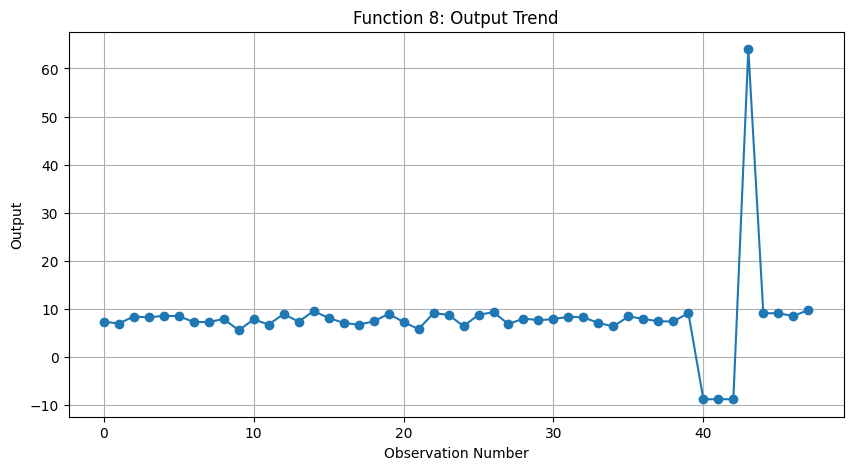

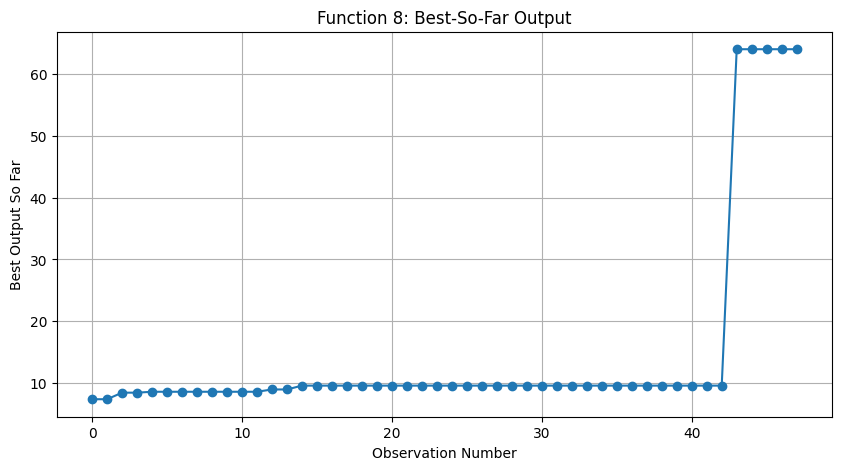


8. CORRELATION WITH OUTPUT


,output
output,1.000000
best_so_far,0.447444
x5,0.005785
x6,-0.006133
x4,-0.019959
x2,-0.030209
x7,-0.049445
x3,-0.070188
x1,-0.074584
x8,-0.123343


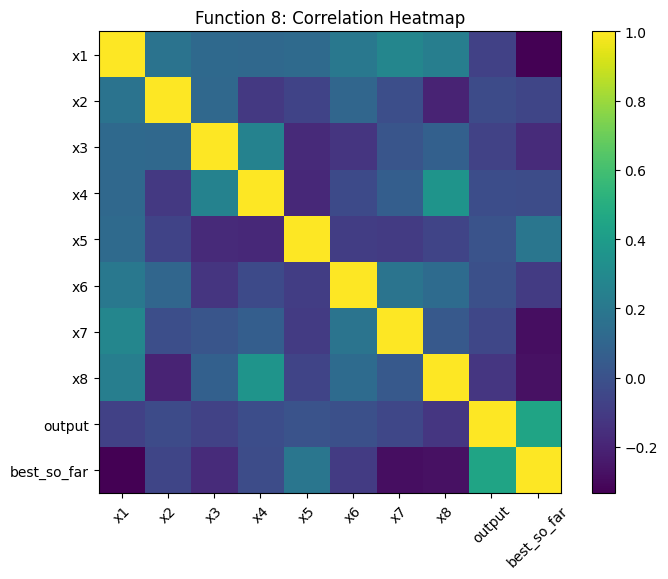

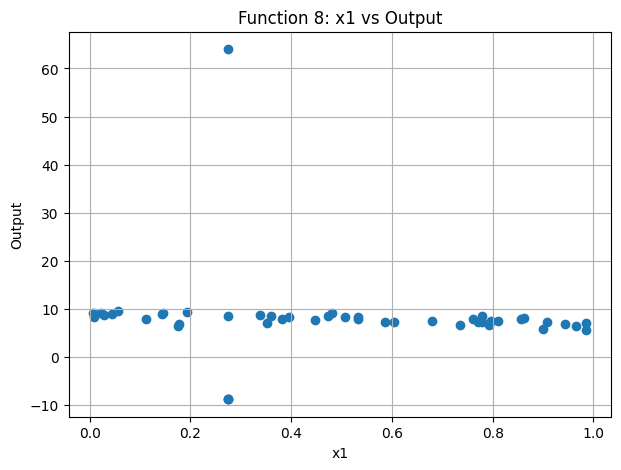

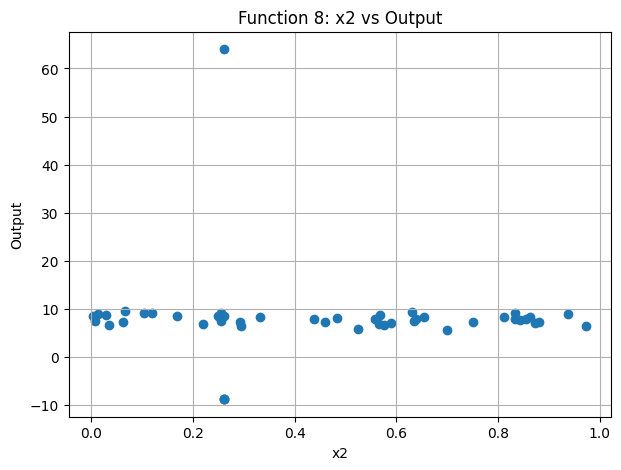

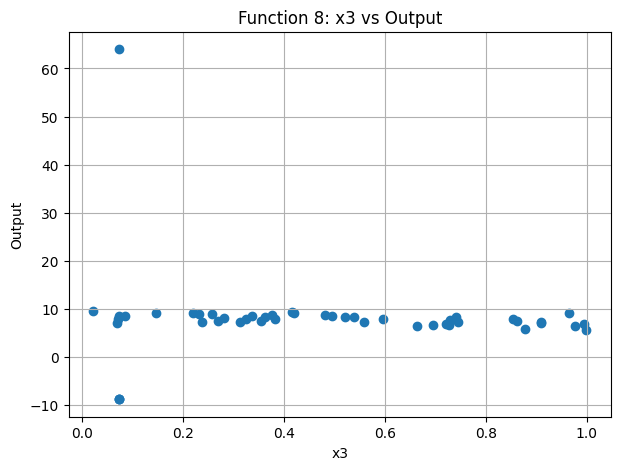

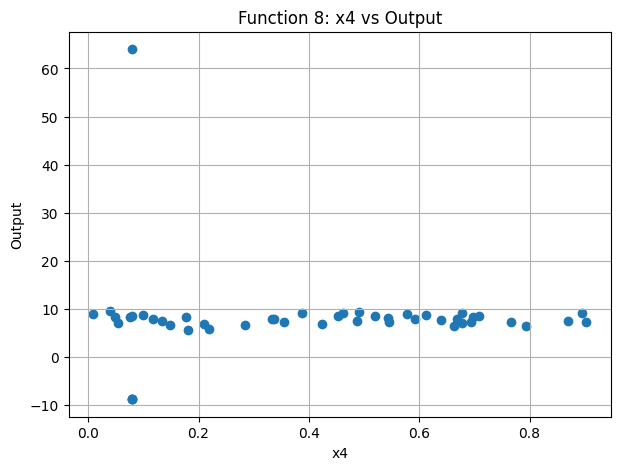

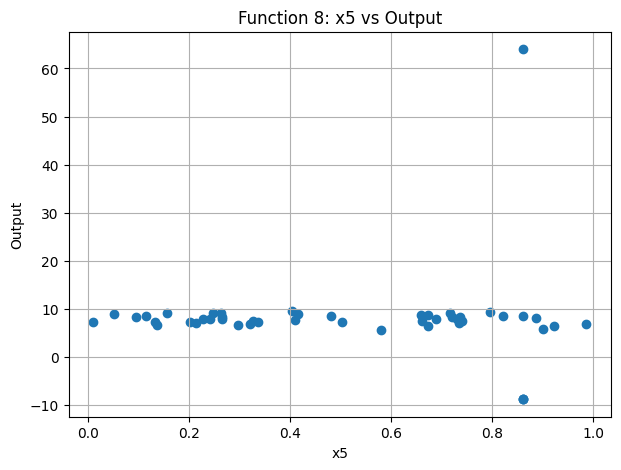

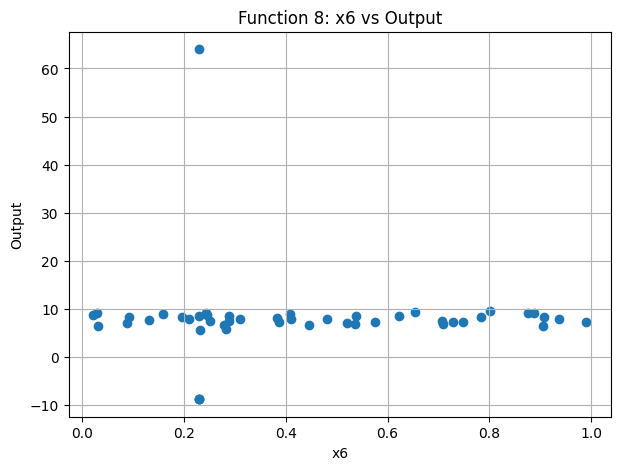

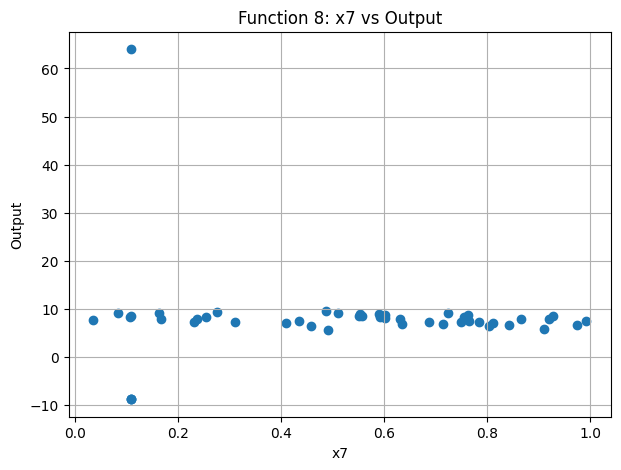

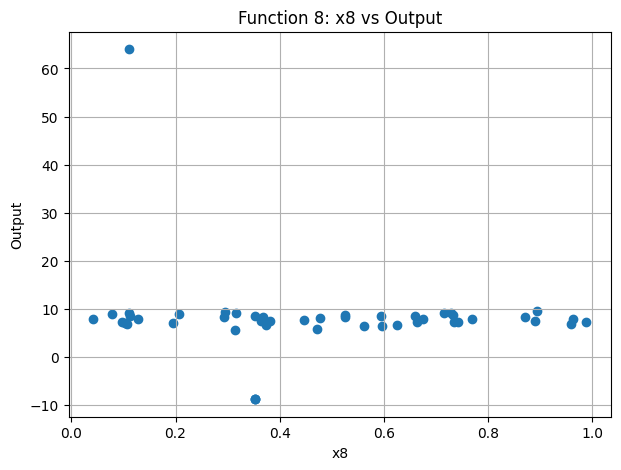

In [71]:
# EDA FOR FUNCTION 8
df_function_8 = run_function_eda(function_id=8)

1. Import libraries and set **paths**

In [104]:

# WEEK 9 BAYESIAN OPTIMISATION SETUP
# GP surrogate + Combined kernels + Expected Improvement
# 80% exploitation + 20% exploration


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
)

2. Set your Week 9 dataset **path**

In [105]:

# CHECK WEEK 9 DATASET LOCATION

possible_paths = [
    "/content/week_9_dataset",
    "/content/drive/MyDrive/week_9_dataset",
    "/content/drive/MyDrive/week_9_dataset/week_9_dataset"
]

week9_path = None

for path in possible_paths:
    if os.path.exists(path):
        week9_path = path
        break

if week9_path is None:
    raise FileNotFoundError(
        "week_9_dataset folder was not found. "
        "Check whether it is in /content or /content/drive/MyDrive."
    )

print("Week 9 dataset found at:")
print(week9_path)

print("\nFiles inside week_9_dataset:")
print(os.listdir(week9_path))

Week 9 dataset found at:
/content/week_9_dataset

Files inside week_9_dataset:
['function_1_outputs.npy', 'function_8_inputs.npy', 'function_2_inputs.npy', 'function_6_outputs.npy', 'function_5_outputs.npy', 'function_7_outputs.npy', 'function_8_inputs_backup_before_fix.npy', 'function_2_outputs.npy', 'function_8_outputs_backup_before_fix.npy', 'function_4_inputs.npy', 'function_1_inputs.npy', 'function_7_inputs.npy', 'function_3_inputs.npy', 'function_6_inputs.npy', 'function_5_inputs.npy', 'function_4_outputs.npy', 'function_3_outputs.npy', 'function_8_outputs.npy']


3. **Helper** function to load each function dataset

In [106]:
import os
import numpy as np
import pandas as pd

def load_function_data(function_number, dataset_folder):
    """
    Load one function's inputs and outputs from .npy files.
    Example files:
    function_1_inputs.npy
    function_1_outputs.npy
    """

    input_file = os.path.join(dataset_folder, f"function_{function_number}_inputs.npy")
    output_file = os.path.join(dataset_folder, f"function_{function_number}_outputs.npy")

    if not os.path.exists(input_file):
        raise FileNotFoundError(f"Missing input file: {input_file}")

    if not os.path.exists(output_file):
        raise FileNotFoundError(f"Missing output file: {output_file}")

    X = np.load(input_file)
    y = np.load(output_file)

    # Make sure y is 1-dimensional
    y = np.ravel(y)

    # Create dataframe for easy viewing
    input_columns = [f"x{i+1}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=input_columns)
    df["output"] = y

    print(f"Function {function_number} loaded successfully.")
    print("Input file:", input_file)
    print("Output file:", output_file)
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return df, X, y

4. Expected Improvement acquisition **function**

In [107]:

# EXPECTED IMPROVEMENT FOR MAXIMISATION


def expected_improvement(X_candidates, gp, y_best, xi=0.01):
    """
    Expected Improvement acquisition function for maximisation.

    X_candidates: candidate input points
    gp: fitted Gaussian Process model
    y_best: current best observed output
    xi: small exploration parameter
    """

    mu, sigma = gp.predict(X_candidates, return_std=True)

    sigma = sigma.reshape(-1)
    mu = mu.reshape(-1)

    improvement = mu - y_best - xi

    with np.errstate(divide="warn"):
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    ei[sigma == 0.0] = 0.0

    return ei

5. Avoid repeating old query **points**

In [108]:

# REMOVE OLD / REPEATED QUERY POINTS

def remove_repeated_points(X_candidates, X_old, decimals=6):
    """
    Removes candidate points that already exist in the old dataset.
    Rounding is used because floating point numbers may differ very slightly.
    """

    old_points = set(map(tuple, np.round(X_old, decimals)))
    new_candidates = []

    for point in X_candidates:
        rounded_point = tuple(np.round(point, decimals))
        if rounded_point not in old_points:
            new_candidates.append(point)

    return np.array(new_candidates)

6. Generate 80% local exploitation and 20% exploration **candidates**

In [109]:

# GENERATE CANDIDATE POINTS
# 80% LOCAL EXPLOITATION + 20% GLOBAL EXPLORATION


def generate_candidates(
    X,
    y,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    random_seed=42
):
    """
    Generates new candidate points.

    80% local exploitation:
    - Points are generated around the top 5 best existing query points.

    20% exploration:
    - Points are generated randomly across the full [0, 1] space.
    """

    np.random.seed(random_seed)

    n_features = X.shape[1]

    # Sort outputs from highest to lowest
    sorted_indices = np.argsort(y)[::-1]

    top_indices = sorted_indices[:top_k]
    top_points = X[top_indices]
    top_outputs = y[top_indices]

    print("\nTop 5 existing query points by highest output:")
    for rank, idx in enumerate(top_indices, start=1):
        print(f"Rank {rank}")
        print("Index:", idx)
        print("Point:", X[idx])
        print("Output:", y[idx])
        print("-" * 40)

    # Number of exploitation and exploration candidates
    n_exploit = int(total_candidates * exploitation_ratio)
    n_explore = total_candidates - n_exploit

    # ------------------------------
    # 80% local exploitation
    # ------------------------------
    local_candidates = []

    for _ in range(n_exploit):
        base_point = top_points[np.random.randint(0, len(top_points))]

        noise = np.random.normal(
            loc=0.0,
            scale=local_noise,
            size=n_features
        )

        new_point = base_point + noise

        # Keep all values within [0, 1]
        new_point = np.clip(new_point, 0, 1)

        local_candidates.append(new_point)

    local_candidates = np.array(local_candidates)

    # ------------------------------
    # 20% random exploration
    # ------------------------------
    random_candidates = np.random.uniform(
        low=0.0,
        high=1.0,
        size=(n_explore, n_features)
    )

    # Combine both groups
    all_candidates = np.vstack([local_candidates, random_candidates])

    # Remove repeated old query points
    all_candidates = remove_repeated_points(all_candidates, X)

    print("\nCandidate generation summary:")
    print("Number of old points:", X.shape[0])
    print("Number of local exploitation candidates:", n_exploit)
    print("Number of random exploration candidates:", n_explore)
    print("Number of candidates after removing repeats:", all_candidates.shape[0])

    return all_candidates, top_points, top_outputs

7. Fit GP with combined **kernels**

In [110]:

# FIT GAUSSIAN PROCESS WITH COMBINED KERNELS


def fit_gp_with_combined_kernel(X, y):
    """
    Fits Gaussian Process surrogate model using combined kernels.
    """

    n_features = X.shape[1]

    combined_kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(
            length_scale=np.ones(n_features),
            length_scale_bounds=(1e-2, 1e2),
            nu=2.5
        )
        + RBF(
            length_scale=np.ones(n_features),
            length_scale_bounds=(1e-2, 1e2)
        )
        + RationalQuadratic(
            length_scale=1.0,
            alpha=1.0
        )
        + WhiteKernel(
            noise_level=1e-6,
            noise_level_bounds=(1e-10, 1e-2)
        )
    )

    gp = GaussianProcessRegressor(
        kernel=combined_kernel,
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gp.fit(X, y)

    print("\nFitted GP kernel:")
    print(gp.kernel_)

    return gp

8. Run Bayesian Optimisation for one function

In [111]:

# BAYESIAN OPTIMISATION FOR ONE FUNCTION


def run_bo_for_function(
    function_number,
    dataset_folder,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
):
    """
    Runs one full BO step for a single function.

    Steps:
    1. Load function dataset.
    2. Sort results by highest output.
    3. Select top 5 best query points.
    4. Fit GP surrogate with combined kernels.
    5. Generate 80% local + 20% exploration candidates.
    6. Remove repeated old points.
    7. Use Expected Improvement to select next best query point.
    """

    print("\n" + "=" * 80)
    print(f"STARTING BAYESIAN OPTIMISATION FOR FUNCTION {function_number}")
    print("=" * 80)

    # Load data
    df, X, y = load_function_data(function_number, dataset_folder)

    # Sort dataframe by output column from highest to lowest
    output_col = df.columns[-1]
    sorted_df = df.sort_values(by=output_col, ascending=False)

    print("\nFunction results sorted by highest output:")
    display(sorted_df.head(10))

    # Current best output
    y_best = np.max(y)
    best_index = np.argmax(y)
    best_point = X[best_index]

    print("\nCurrent best observed point:")
    print("Best index:", best_index)
    print("Best query point:", best_point)
    print("Best output:", y_best)

    # Fit GP
    gp = fit_gp_with_combined_kernel(X, y)

    # Generate candidates
    X_candidates, top_points, top_outputs = generate_candidates(
        X=X,
        y=y,
        total_candidates=total_candidates,
        top_k=top_k,
        exploitation_ratio=exploitation_ratio,
        local_noise=local_noise,
        random_seed=42 + function_number
    )

    if X_candidates.shape[0] == 0:
        raise ValueError("No new candidate points left after removing repeats.")

    # Calculate EI
    ei_values = expected_improvement(
        X_candidates=X_candidates,
        gp=gp,
        y_best=y_best,
        xi=xi
    )

    # Select next best point
    best_candidate_index = np.argmax(ei_values)
    next_best_point = X_candidates[best_candidate_index]
    next_best_ei = ei_values[best_candidate_index]

    # GP prediction at selected point
    predicted_mean, predicted_std = gp.predict(
        next_best_point.reshape(1, -1),
        return_std=True
    )

    print("\nNEXT BEST QUERY POINT SELECTED BY EXPECTED IMPROVEMENT:")
    print("Function:", function_number)
    print("Next best query point:", next_best_point)
    print("Expected Improvement:", next_best_ei)
    print("Predicted mean output:", predicted_mean[0])
    print("Predicted uncertainty/std:", predicted_std[0])

    result = {
        "function": function_number,
        "next_point": next_best_point,
        "expected_improvement": next_best_ei,
        "predicted_mean": predicted_mean[0],
        "predicted_std": predicted_std[0],
        "current_best_output": y_best,
        "current_best_point": best_point
    }

    return result, sorted_df, gp

**9. Run Function 1**

In [113]:
result_1, sorted_f1, gp_1 = run_bo_for_function(
    function_number=1,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 1
Function 1 loaded successfully.
Input file: /content/week_9_dataset/function_1_inputs.npy
Output file: /content/week_9_dataset/function_1_outputs.npy
X shape: (18, 2)
y shape: (18,)

Function results sorted by highest output:


,x1,x2,output
12,0.374540,0.950714,6.400000e+01
13,0.374540,0.950714,6.400000e+01
11,0.374540,0.950714,6.400000e+01
10,0.374540,0.950714,6.400000e+01
2,0.731024,0.733000,7.710875e-16
7,0.683418,0.861057,2.535001e-40
1,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48
0,0.319404,0.762959,1.322677e-79
8,0.082507,0.403488,3.606771e-81



Current best observed point:
Best index: 10
Best query point: [0.37454  0.950714]
Best output: 64.0

Fitted GP kernel:
0.559**2 * Matern(length_scale=[100, 0.0258], nu=2.5) + RBF(length_scale=[100, 3.67]) + RationalQuadratic(alpha=1e-05, length_scale=7.96e+03) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 13
Point: [0.37454  0.950714]
Output: 64.0
----------------------------------------
Rank 2
Index: 12
Point: [0.37454  0.950714]
Output: 64.0
----------------------------------------
Rank 3
Index: 10
Point: [0.37454  0.950714]
Output: 64.0
----------------------------------------
Rank 4
Index: 11
Point: [0.37454  0.950714]
Output: 64.0
----------------------------------------
Rank 5
Index: 2
Point: [0.73102363 0.73299988]
Output: 7.710875114502849e-16
----------------------------------------

Candidate generation summary:
Number of old points: 18
Number of local exploitation candidates: 800
Number of random exploration candidates: 200
Nu

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452:

**10. Run Function 2**

In [114]:
result_2, sorted_f2, gp_2 = run_bo_for_function(
    function_number=2,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 2
Function 2 loaded successfully.
Input file: /content/week_9_dataset/function_2_inputs.npy
Output file: /content/week_9_dataset/function_2_outputs.npy
X shape: (18, 2)
y shape: (18,)

Function results sorted by highest output:


,x1,x2,output
13,0.374540,0.950714,64.000000
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993
6,0.438166,0.685018,0.244619
14,0.555332,0.360931,0.220781
15,0.555332,0.360931,0.220781
4,0.454647,0.290455,0.214965
16,0.009675,0.999881,0.048714



Current best observed point:
Best index: 13
Best query point: [0.37454  0.950714]
Best output: 64.0

Fitted GP kernel:
0.291**2 * Matern(length_scale=[0.199, 0.22], nu=2.5) + RBF(length_scale=[100, 100]) + RationalQuadratic(alpha=0.00517, length_scale=1.94e+03) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 13
Point: [0.37454  0.950714]
Output: 64.0
----------------------------------------
Rank 2
Index: 9
Point: [0.70263656 0.9265642 ]
Output: 0.6112052157614438
----------------------------------------
Rank 3
Index: 0
Point: [0.66579958 0.12396913]
Output: 0.5389961189269181
----------------------------------------
Rank 4
Index: 1
Point: [0.87779099 0.7786275 ]
Output: 0.42058623962798264
----------------------------------------
Rank 5
Index: 3
Point: [0.84527543 0.71112027]
Output: 0.293992912410866
----------------------------------------

Candidate generation summary:
Number of old points: 18
Number of local exploitation candidates: 80

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


**11. Run Function 3**

In [115]:
result_3, sorted_f3, gp_3 = run_bo_for_function(
    function_number=3,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 3
Function 3 loaded successfully.
Input file: /content/week_9_dataset/function_3_inputs.npy
Output file: /content/week_9_dataset/function_3_outputs.npy
X shape: (23, 3)
y shape: (23,)

Function results sorted by highest output:


,x1,x2,x3,output
16,0.444444,0.666666,0.333333,64.000000
17,0.444444,0.666666,0.333333,64.000000
18,0.444444,0.666666,0.333333,64.000000
15,0.444444,0.666666,0.333333,64.000000
3,0.492581,0.611593,0.340176,-0.034835
13,0.600097,0.725136,0.066089,-0.036378
22,0.444444,0.666666,0.333333,-0.040908
10,0.220549,0.297825,0.343555,-0.046947
21,0.427731,0.669810,0.343678,-0.047183
4,0.134622,0.219917,0.458206,-0.048008



Current best observed point:
Best index: 15
Best query point: [0.444444 0.666666 0.333333]
Best output: 64.0

Fitted GP kernel:
0.517**2 * Matern(length_scale=[0.01, 0.01, 62.4], nu=2.5) + RBF(length_scale=[100, 100, 100]) + RationalQuadratic(alpha=5.29e-05, length_scale=2.94e+03) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 16
Point: [0.444444 0.666666 0.333333]
Output: 64.0
----------------------------------------
Rank 2
Index: 17
Point: [0.444444 0.666666 0.333333]
Output: 64.0
----------------------------------------
Rank 3
Index: 18
Point: [0.444444 0.666666 0.333333]
Output: 64.0
----------------------------------------
Rank 4
Index: 15
Point: [0.444444 0.666666 0.333333]
Output: 64.0
----------------------------------------
Rank 5
Index: 3
Point: [0.49258141 0.61159319 0.34017639]
Output: -0.034835313350078584
----------------------------------------

Candidate generation summary:
Number of old points: 23
Number of local exploita

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k1__k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/ke

**12. Run Function 4**

In [116]:
result_4, sorted_f4, gp_4 = run_bo_for_function(
    function_number=4,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 4
Function 4 loaded successfully.
Input file: /content/week_9_dataset/function_4_inputs.npy
Output file: /content/week_9_dataset/function_4_outputs.npy
X shape: (38, 4)
y shape: (38,)

Function results sorted by highest output:


,x1,x2,x3,x4,output
33,0.555555,0.444444,0.222222,0.111111,64.000000
31,0.555555,0.444444,0.222222,0.111111,-0.031830
30,0.555555,0.444444,0.222222,0.111111,-0.031830
32,0.555555,0.444444,0.222222,0.111111,-0.031830
27,0.577766,0.428772,0.425826,0.249007,-4.025542
24,0.326076,0.472367,0.453192,0.105887,-6.702089
23,0.282138,0.505987,0.530531,0.096302,-7.966775
37,0.555555,0.444444,0.222222,0.111111,-8.727516
4,0.124871,0.129770,0.384400,0.287076,-10.069633
21,0.170347,0.756959,0.276520,0.531231,-11.565742



Current best observed point:
Best index: 33
Best query point: [0.555555 0.444444 0.222222 0.111111]
Best output: 64.0

Fitted GP kernel:
0.439**2 * Matern(length_scale=[100, 0.519, 0.165, 0.586], nu=2.5) + RBF(length_scale=[0.508, 0.535, 100, 27.6]) + RationalQuadratic(alpha=7.57e+03, length_scale=3.58e+04) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 33
Point: [0.555555 0.444444 0.222222 0.111111]
Output: 64.0
----------------------------------------
Rank 2
Index: 32
Point: [0.555555 0.444444 0.222222 0.111111]
Output: -0.03182956281754251
----------------------------------------
Rank 3
Index: 30
Point: [0.555555 0.444444 0.222222 0.111111]
Output: -0.03182956281754251
----------------------------------------
Rank 4
Index: 31
Point: [0.555555 0.444444 0.222222 0.111111]
Output: -0.03182956281754251
----------------------------------------
Rank 5
Index: 27
Point: [0.57776561 0.42877174 0.42582587 0.24900741]
Output: -4.025542281908162
-

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


**13. Run Function 5**

In [117]:
result_5, sorted_f5, gp_5 = run_bo_for_function(
    function_number=5,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 5
Function 5 loaded successfully.
Input file: /content/week_9_dataset/function_5_inputs.npy
Output file: /content/week_9_dataset/function_5_outputs.npy
X shape: (28, 4)
y shape: (28,)

Function results sorted by highest output:


,x1,x2,x3,x4,output
15,0.224189,0.846480,0.879484,0.878516,1088.859618
27,0.224189,0.846480,0.879484,0.878515,1088.853511
18,0.119879,0.862540,0.643331,0.849804,431.612757
14,0.438933,0.774092,0.378167,0.933696,355.806818
4,0.836478,0.193610,0.663893,0.785649,258.370525
9,0.463442,0.630025,0.107906,0.957644,233.223610
26,0.000000,0.000000,0.000000,0.000000,163.122500
7,0.352356,0.322242,0.116979,0.473113,109.571876
13,0.511142,0.817957,0.728710,0.112354,79.729130
5,0.683432,0.118663,0.829046,0.567577,78.434389



Current best observed point:
Best index: 15
Best query point: [0.22418902 0.84648049 0.87948418 0.87851568]
Best output: 1088.8596181962705

Fitted GP kernel:
0.0316**2 * Matern(length_scale=[4.61, 75.8, 13.8, 57.3], nu=2.5) + RBF(length_scale=[100, 100, 100, 0.798]) + RationalQuadratic(alpha=1e+05, length_scale=1e-05) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 15
Point: [0.22418902 0.84648049 0.87948418 0.87851568]
Output: 1088.8596181962705
----------------------------------------
Rank 2
Index: 27
Point: [0.224189 0.84648  0.879484 0.878515]
Output: 1088.8535114737463
----------------------------------------
Rank 3
Index: 18
Point: [0.11987923 0.86254031 0.64333133 0.84980383]
Output: 431.6127567592104
----------------------------------------
Rank 4
Index: 14
Point: [0.43893338 0.77409176 0.37816709 0.93369621]
Output: 355.8068177560159
----------------------------------------
Rank 5
Index: 4
Point: [0.83647799 0.19360965 0.6638927 

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/ke

**14. Run Function 6**

In [118]:
result_6, sorted_f6, gp_6 = run_bo_for_function(
    function_number=6,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 6
Function 6 loaded successfully.
Input file: /content/week_9_dataset/function_6_inputs.npy
Output file: /content/week_9_dataset/function_6_outputs.npy
X shape: (28, 5)
y shape: (28,)

Function results sorted by highest output:


,x1,x2,x3,x4,x5,output
23,0.728186,0.154693,0.732552,0.693997,0.564013,64.000000
21,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
22,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
20,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
17,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757
10,0.536797,0.308781,0.411879,0.388225,0.522528,-1.144785
27,0.728186,0.154693,0.732552,0.693997,0.564013,-1.152035
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955



Current best observed point:
Best index: 23
Best query point: [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output: 64.0

Fitted GP kernel:
0.252**2 * Matern(length_scale=[0.01, 0.01, 0.01, 0.01, 0.01], nu=2.5) + RBF(length_scale=[100, 76.7, 100, 100, 100]) + RationalQuadratic(alpha=1e-05, length_scale=1e-05) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 23
Point: [0.728186 0.154693 0.732552 0.693997 0.564013]
Output: 64.0
----------------------------------------
Rank 2
Index: 20
Point: [0.728186 0.154693 0.732552 0.693997 0.564013]
Output: -0.04090761844901528
----------------------------------------
Rank 3
Index: 22
Point: [0.728186 0.154693 0.732552 0.693997 0.564013]
Output: -0.04090761844901528
----------------------------------------
Rank 4
Index: 21
Point: [0.728186 0.154693 0.732552 0.693997 0.564013]
Output: -0.04090761844901528
----------------------------------------
Rank 5
Index: 0
Point: [0.7281861  0.15469257 0.732551

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k1__k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k1__k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process

**15. Run Function 7**

In [119]:
result_7, sorted_f7, gp_7 = run_bo_for_function(
    function_number=7,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 7
Function 7 loaded successfully.
Input file: /content/week_9_dataset/function_7_inputs.npy
Output file: /content/week_9_dataset/function_7_outputs.npy
X shape: (38, 6)
y shape: (38,)

Function results sorted by highest output:


,x1,x2,x3,x4,x5,x6,output
31,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
30,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
33,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
32,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
37,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,1.051015
36,0.121173,0.544849,0.282921,0.037758,0.374685,0.591179,0.899949
24,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142
14,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433



Current best observed point:
Best index: 30
Best query point: [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output: 64.0

Fitted GP kernel:
0.0316**2 * Matern(length_scale=[100, 63.2, 45.5, 100, 89.1, 53.4], nu=2.5) + RBF(length_scale=[100, 100, 100, 100, 0.0126, 100]) + RationalQuadratic(alpha=1e-05, length_scale=1e+05) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 33
Point: [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Output: 64.0
----------------------------------------
Rank 2
Index: 32
Point: [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Output: 64.0
----------------------------------------
Rank 3
Index: 30
Point: [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Output: 64.0
----------------------------------------
Rank 4
Index: 31
Point: [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Output: 64.0
----------------------------------------
Rank 5
Index: 6
Point: [0.05789554 0.49167222

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_pr

**17. Run Function 8**

In [121]:
result_8, sorted_f8, gp_8 = run_bo_for_function(
    function_number=8,
    dataset_folder=week9_path,
    total_candidates=1000,
    top_k=5,
    exploitation_ratio=0.80,
    local_noise=0.05,
    xi=0.01
)


STARTING BAYESIAN OPTIMISATION FOR FUNCTION 8
Function 8 loaded successfully.
Input file: /content/week_9_dataset/function_8_inputs.npy
Output file: /content/week_9_dataset/function_8_outputs.npy
X shape: (47, 8)
y shape: (47,)

Function results sorted by highest output:


,x1,x2,x3,x4,x5,x6,x7,x8,output
43,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.110992,64.000000
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
26,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274
39,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005
22,0.145120,0.119328,0.420888,0.387609,0.155423,0.875172,0.510560,0.728611,9.141639
45,0.006802,0.833571,0.147083,0.461921,0.263530,0.887722,0.724982,0.315234,9.138609
44,0.022977,0.255313,0.963757,0.895383,0.716713,0.030436,0.083412,0.110992,9.138609
19,0.044329,0.013581,0.258198,0.577644,0.051280,0.158563,0.591030,0.077953,9.013075
12,0.143550,0.937415,0.232325,0.009043,0.414579,0.409325,0.553779,0.205841,8.976554
25,0.028947,0.028279,0.481372,0.613175,0.672660,0.022113,0.601483,0.524885,8.830745



Current best observed point:
Best index: 43
Best query point: [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output: 64.0

Fitted GP kernel:
0.0316**2 * Matern(length_scale=[65.5, 100, 100, 100, 100, 100, 99.9, 27.6], nu=2.5) + RBF(length_scale=[100, 100, 0.403, 100, 100, 100, 0.312, 0.139]) + RationalQuadratic(alpha=1.22e-05, length_scale=1e+05) + WhiteKernel(noise_level=0.01)

Top 5 existing query points by highest output:
Rank 1
Index: 43
Point: [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Output: 64.0
----------------------------------------
Rank 2
Index: 14
Point: [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
 0.48830701 0.89308498]
Output: 9.598482002566342
----------------------------------------
Rank 3
Index: 26
Point: [0.19263987 0.63067728 0.41679584 0.49052929 0.79608602 0.65456706
 0.27624119 0.29551759]
Output: 9.34427428080805
----------------------------------------
Rank 4
Index: 39
Point:

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k1__k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_pr

**Combine all selected Week 9 query points**

In [122]:

# COMBINE ALL WEEK 9 SELECTED QUERY POINTS


all_results = [
    result_1,
    result_2,
    result_3,
    result_4,
    result_5,
    result_6,
    result_7,
    result_8
]

summary_rows = []

for result in all_results:
    function_number = result["function"]
    next_point = result["next_point"]

    row = {
        "Function": function_number,
        "Expected_Improvement": result["expected_improvement"],
        "Predicted_Mean": result["predicted_mean"],
        "Predicted_Std": result["predicted_std"],
        "Current_Best_Output": result["current_best_output"]
    }

    for i, value in enumerate(next_point, start=1):
        row[f"x{i}"] = value

    summary_rows.append(row)

week9_query_points = pd.DataFrame(summary_rows)

print("Final Week 9 query points:")
display(week9_query_points)

Final Week 9 query points:


,Function,Expected_Improvement,Predicted_Mean,Predicted_Std,Current_Best_Output,x1,x2,x3,x4,x5,x6,x7,x8
0,1,2.980194e-02,41.303565,9.633293,64.000000,0.421410,0.935804,NaN,NaN,NaN,NaN,NaN,NaN
1,2,6.478523e-42,1.441361,4.657191,64.000000,0.995366,0.102732,NaN,NaN,NaN,NaN,NaN,NaN
2,3,6.855347e-03,42.964785,7.649925,64.000000,0.449035,0.664262,0.290384,NaN,NaN,NaN,NaN,NaN
3,4,1.171087e-39,-25.830360,6.870569,64.000000,0.889493,0.002958,0.445975,0.774547,NaN,NaN,NaN,NaN
4,5,2.052716e-01,244.962794,298.219614,1088.859618,0.319924,0.675406,0.431628,1.000000,NaN,NaN,NaN,NaN
5,6,1.242547e-82,-0.302412,3.361868,64.000000,0.711755,0.175670,0.738396,0.689597,0.562717,NaN,NaN,NaN
6,7,1.065571e+00,54.329412,10.700897,64.000000,0.018603,0.530937,0.376818,0.094048,0.443567,0.614974,NaN,NaN
7,8,1.858428e+00,65.119562,3.069364,64.000000,0.321258,0.232284,0.021301,0.000000,0.895967,0.249315,0.054463,0.073967


**Save Week 9 query points to Google **

In [126]:

# SAVE WEEK 9 QUERY POINTS


save_path = "/content/drive/MyDrive/week_9_selected_query_points.csv"

week9_query_points.to_csv(save_path, index=False)

print("Week 9 selected query points saved to:")
print(save_path)

Week 9 selected query points saved to:
/content/drive/MyDrive/week_9_selected_query_points.csv
